# Heart Disease Prediction Using Supervised Machine Learning

This project develops and evaluates four supervised machine-learning classification models for predicting the presence of heart disease:

- Artificial Neural Network (ANN)
- Support Vector Machine (SVM)
- Random Forest
- XGBoost

# PHASE 1 — PROJECT SETUP

In [3]:
# ============================================================
# PHASE 1.1 — IMPORT REQUIRED LIBRARIES
# ============================================================

from pathlib import Path
import random
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn import __version__ as sklearn_version

print("Libraries imported successfully.")
print("scikit-learn version:", sklearn_version)

Libraries imported successfully.
scikit-learn version: 1.5.1


In [4]:
# ============================================================
# PHASE 1.2 — DEFINE PROJECT DIRECTORIES
# ============================================================

# Use the folder containing this notebook as the project root
PROJECT_ROOT = Path.cwd()

# Main data directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "outputs"

# Results directories
RESULTS_DIR = PROJECT_ROOT / "results"
CHARTS_DIR = RESULTS_DIR / "charts"
TABLES_DIR = RESULTS_DIR / "tables"

# Model and checkpoint directories
MODELS_DIR = PROJECT_ROOT / "models"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"

# Create the required main folders
main_directories = [
    DATA_DIR,
    RAW_DATA_DIR,
    OUTPUT_DATA_DIR,
    RESULTS_DIR,
    CHARTS_DIR,
    TABLES_DIR,
    MODELS_DIR,
    CHECKPOINTS_DIR
]

for directory in main_directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directories created successfully.")
print("Project root:", PROJECT_ROOT)

Project directories created successfully.
Project root: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL


In [178]:
# ============================================================
# PHASE 1.3 — OUTPUT-SAVING FUNCTIONS
# ============================================================

def save_chart(filename, subfolder, fig=None):
    folder = CHARTS_DIR / subfolder
    folder.mkdir(parents=True, exist_ok=True)

    filepath = folder / filename

    if fig is None:
        fig = plt.gcf()

    fig.savefig(
        filepath,
        dpi=400,
        bbox_inches="tight"
    )

    print(f"Saved chart: {filepath}")

    return filepath


def save_table(dataframe, filename, index=False):
    TABLES_DIR.mkdir(parents=True, exist_ok=True)

    filepath = TABLES_DIR / filename

    dataframe.to_csv(
        filepath,
        index=index
    )

    print(f"Saved table: {filepath}")

    return filepath


print("Saving functions created successfully.")

Saving functions created successfully.


In [6]:
# ============================================================
# PHASE 1.4 — RANDOM SEED AND REPRODUCIBILITY
# ============================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

print("Random seed set successfully.")
print("Random state:", RANDOM_STATE)

Random seed set successfully.
Random state: 42


# PHASE 2 — DATASET LOADING AND INITIAL INSPECTION

In [7]:
# ============================================================
# PHASE 2.1 — LOAD DATASET
# ============================================================

DATASET_PATH = RAW_DATA_DIR / "heart.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")
print("Dataset path:", DATASET_PATH)
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset path: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/data/raw/heart.csv
Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [8]:
# ============================================================
# PHASE 2.2 — INITIAL DATASET INSPECTION
# ============================================================

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (918, 12)

Column names:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [9]:
# ============================================================
# PHASE 2.3 — DATASET SUMMARY
# ============================================================

# Display descriptive statistics for all variables
dataset_summary = df.describe(include="all").T

print("Dataset summary:")
display(dataset_summary)

# Display number of unique values in each column
unique_values = df.nunique().to_frame(name="Unique Values")

print("\nNumber of unique values in each column:")
display(unique_values)

Dataset summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2



Number of unique values in each column:


,Unique Values
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


In [10]:
# ============================================================
# PHASE 2.4 — SAVE DATASET SUMMARY
# ============================================================

save_table(
    dataset_summary.reset_index().rename(columns={"index": "Feature"}),
    "dataset_summary.csv",
    index=False
)

save_table(
    unique_values.reset_index().rename(columns={"index": "Feature"}),
    "unique_values_summary.csv",
    index=False
)

print("Dataset summary tables saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/dataset_summary.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/unique_values_summary.csv
Dataset summary tables saved successfully.


# PHASE 3 — DATA QUALITY ASSESSMENT

In [11]:
# ============================================================
# PHASE 3.1 — CHECK MISSING VALUES
# ============================================================

missing_values = df.isnull().sum().to_frame(name="Missing Values")

missing_values["Missing Percentage"] = (
    missing_values["Missing Values"] / len(df) * 100
).round(2)

print("Missing values summary:")
display(missing_values)

print(
    "\nTotal missing values in dataset:",
    missing_values["Missing Values"].sum()
)

Missing values summary:


,Missing Values,Missing Percentage
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0



Total missing values in dataset: 0


In [12]:
# ============================================================
# PHASE 3.2 — CHECK DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round((duplicate_count / len(df)) * 100, 2),
    "%"
)

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


In [13]:
# ============================================================
# PHASE 3.3 — SAVE INITIAL DATA QUALITY SUMMARY
# ============================================================

# Save missing-value summary
save_table(
    missing_values.reset_index().rename(columns={"index": "Feature"}),
    "missing_values_summary.csv",
    index=False
)

# Create duplicate summary table
duplicate_summary = pd.DataFrame({
    "Check": [
        "Total Records",
        "Duplicate Records",
        "Duplicate Percentage"
    ],
    "Value": [
        len(df),
        duplicate_count,
        round((duplicate_count / len(df)) * 100, 2)
    ]
})

# Save duplicate summary
save_table(
    duplicate_summary,
    "duplicate_summary.csv",
    index=False
)

print("Initial data quality summaries saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/missing_values_summary.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/duplicate_summary.csv
Initial data quality summaries saved successfully.


In [14]:
# ============================================================
# PHASE 3.4 — INSPECT CATEGORICAL VALUES
# ============================================================

categorical_columns = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "HeartDisease"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(df[column].value_counts(dropna=False).sort_index())


Sex
---
Sex
F    193
M    725
Name: count, dtype: int64

ChestPainType
-------------
ChestPainType
ASY    496
ATA    173
NAP    203
TA      46
Name: count, dtype: int64

FastingBS
---------
FastingBS
0    704
1    214
Name: count, dtype: int64

RestingECG
----------
RestingECG
LVH       188
Normal    552
ST        178
Name: count, dtype: int64

ExerciseAngina
--------------
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
--------
ST_Slope
Down     63
Flat    460
Up      395
Name: count, dtype: int64

HeartDisease
------------
HeartDisease
0    410
1    508
Name: count, dtype: int64


In [15]:
# ============================================================
# PHASE 3.5 — CHECK SUSPICIOUS ZERO VALUES
# ============================================================

zero_check_columns = [
    "RestingBP",
    "Cholesterol",
    "MaxHR"
]

zero_summary = []

for column in zero_check_columns:
    zero_count = (df[column] == 0).sum()

    zero_summary.append({
        "Feature": column,
        "Zero Count": zero_count,
        "Zero Percentage": round((zero_count / len(df)) * 100, 2)
    })

zero_summary = pd.DataFrame(zero_summary)

print("Suspicious zero-value summary:")
display(zero_summary)

Suspicious zero-value summary:


,Feature,Zero Count,Zero Percentage
0,RestingBP,1,0.11
1,Cholesterol,172,18.74
2,MaxHR,0,0.00


In [16]:
# ============================================================
# PHASE 3.6 — SAVE SUSPICIOUS ZERO-VALUE SUMMARY
# ============================================================

save_table(
    zero_summary,
    "suspicious_zero_values_summary.csv",
    index=False
)

print("Suspicious zero-value summary saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/suspicious_zero_values_summary.csv
Suspicious zero-value summary saved successfully.


# PHASE 4 — DATA CLEANING

In [17]:
# ============================================================
# PHASE 4.1 — CREATE CLEANED DATASET
# ============================================================

# Create a copy so the original raw dataset remains unchanged
df_clean = df.copy()

# Convert clinically invalid zero values to missing values
df_clean.loc[df_clean["RestingBP"] == 0, "RestingBP"] = np.nan
df_clean.loc[df_clean["Cholesterol"] == 0, "Cholesterol"] = np.nan

print("Invalid zero values converted to NaN successfully.")

print("\nMissing values after cleaning:")
display(
    df_clean.isnull()
    .sum()
    .to_frame(name="Missing Values")
)

Invalid zero values converted to NaN successfully.

Missing values after cleaning:


,Missing Values
Age,0
Sex,0
ChestPainType,0
RestingBP,1
Cholesterol,172
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [18]:
# ============================================================
# PHASE 4.2 — SAVE DATA CLEANING SUMMARY
# ============================================================

cleaning_summary = pd.DataFrame({
    "Feature": ["RestingBP", "Cholesterol"],
    "Invalid Zero Values Converted to NaN": [
        (df["RestingBP"] == 0).sum(),
        (df["Cholesterol"] == 0).sum()
    ],
    "Missing Values After Cleaning": [
        df_clean["RestingBP"].isnull().sum(),
        df_clean["Cholesterol"].isnull().sum()
    ]
})

display(cleaning_summary)

save_table(
    cleaning_summary,
    "data_cleaning_summary.csv",
    index=False
)

print("Data cleaning summary saved successfully.")

,Feature,Invalid Zero Values Converted to NaN,Missing Values After Cleaning
0,RestingBP,1,1
1,Cholesterol,172,172


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/data_cleaning_summary.csv
Data cleaning summary saved successfully.


In [19]:
# ============================================================
# PHASE 4.3 — VERIFY CLEANED DATASET
# ============================================================

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nTotal rows removed:", len(df) - len(df_clean))

Original dataset shape: (918, 12)
Cleaned dataset shape: (918, 12)

Total rows removed: 0


# PHASE 5 — EXPLORATORY DATA ANALYSIS

In [20]:
# ============================================================
# PHASE 5.1 — TARGET CLASS DISTRIBUTION
# ============================================================

# Calculate target class counts
class_counts = (
    df_clean["HeartDisease"]
    .value_counts()
    .sort_index()
)

# Create summary table
class_distribution = pd.DataFrame({
    "HeartDisease": class_counts.index,
    "Count": class_counts.values
})

# Add readable class labels
class_distribution["Class Label"] = class_distribution["HeartDisease"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

# Calculate percentages
class_distribution["Percentage"] = (
    class_distribution["Count"] / len(df_clean) * 100
).round(2)

# Reorder columns
class_distribution = class_distribution[
    ["HeartDisease", "Class Label", "Count", "Percentage"]
]

print("Target class distribution:")
display(class_distribution)

Target class distribution:


,HeartDisease,Class Label,Count,Percentage
0,0,No Heart Disease,410,44.66
1,1,Heart Disease,508,55.34


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/dataset/target_class_distribution.png


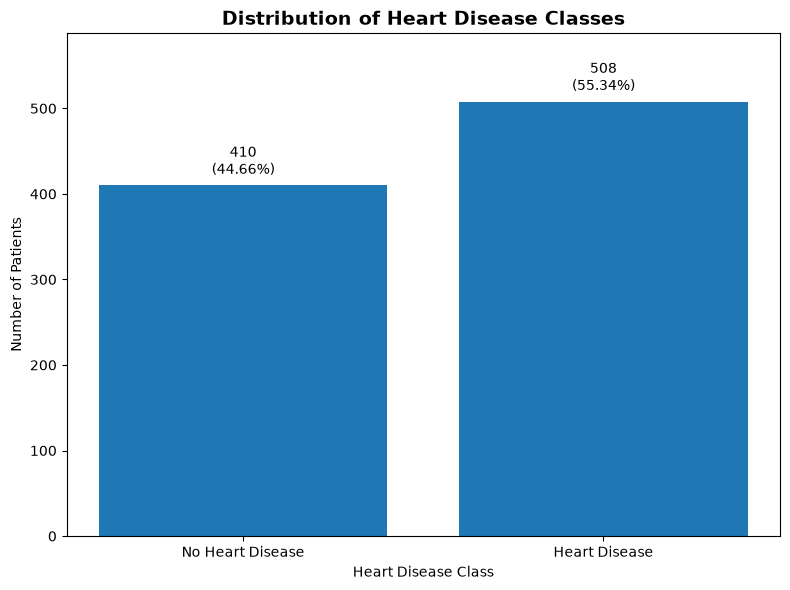

In [21]:
# ============================================================
# PHASE 5.2 — TARGET CLASS DISTRIBUTION CHART
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    class_distribution["Class Label"],
    class_distribution["Count"]
)

ax.set_title(
    "Distribution of Heart Disease Classes",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Heart Disease Class")
ax.set_ylabel("Number of Patients")

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    class_distribution["Count"],
    class_distribution["Percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{count}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

ax.set_ylim(
    0,
    class_distribution["Count"].max() + 80
)

plt.tight_layout()

save_chart(
    "target_class_distribution.png",
    "dataset",
    fig
)

plt.show()

In [22]:
# ============================================================
# PHASE 5.3 — SAVE TARGET CLASS DISTRIBUTION TABLE
# ============================================================

save_table(
    class_distribution,
    "class_distribution.csv",
    index=False
)

print("Target class distribution table saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/class_distribution.csv
Target class distribution table saved successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/age_distribution.png


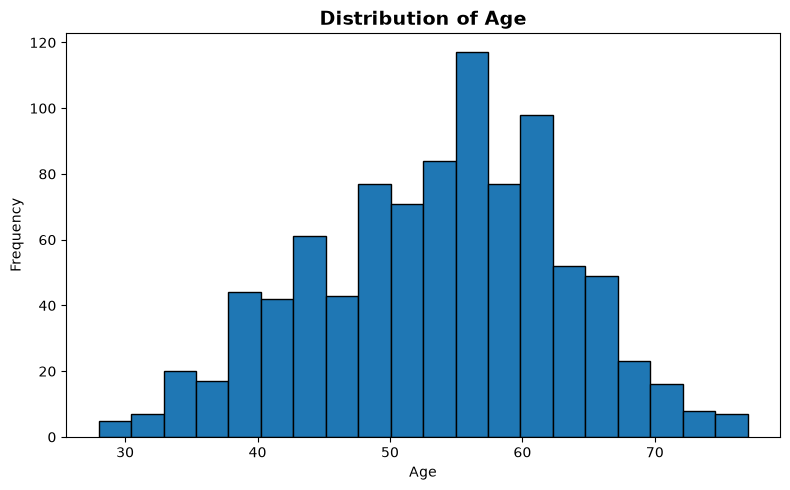

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/restingbp_distribution.png


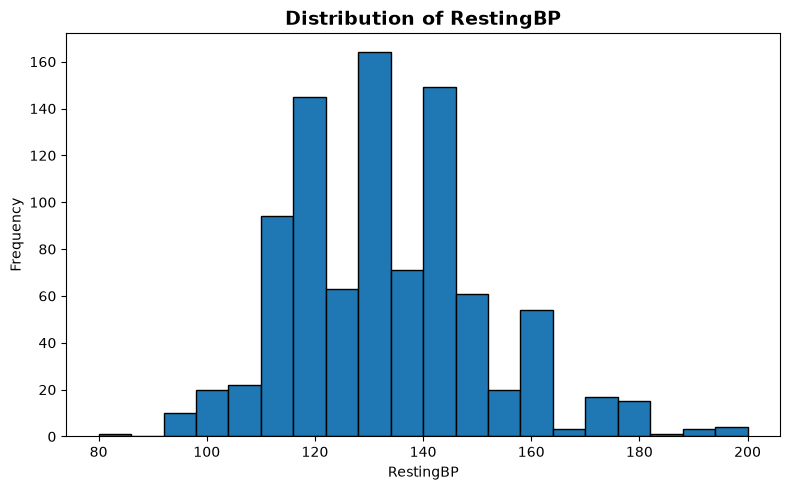

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/cholesterol_distribution.png


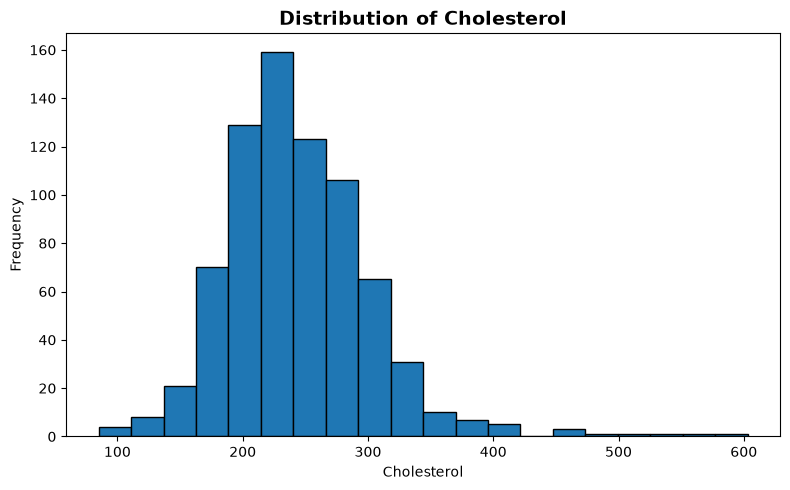

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/maxhr_distribution.png


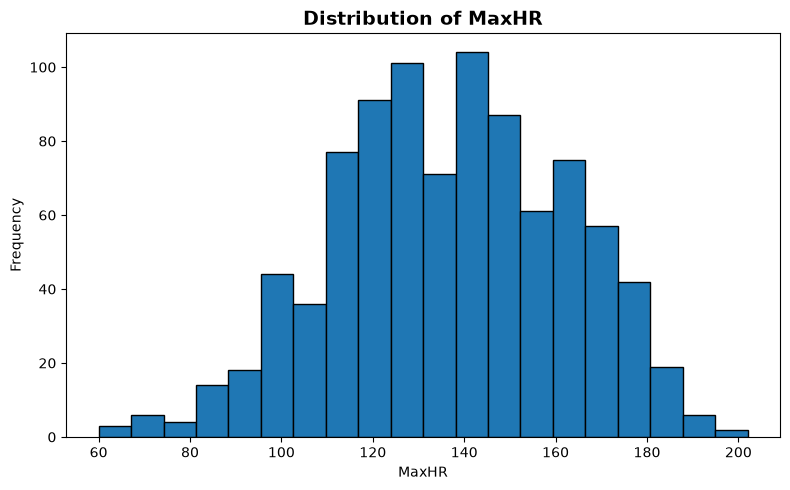

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/oldpeak_distribution.png


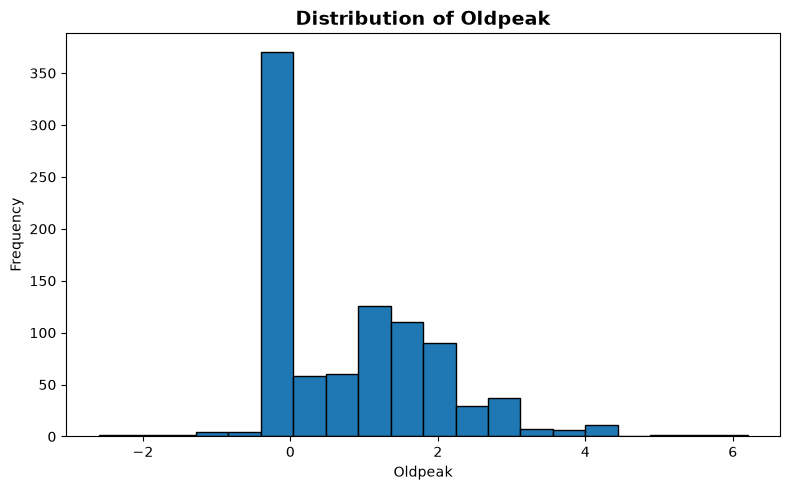

In [23]:
# ============================================================
# PHASE 5.4 — NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

for feature in numerical_features:

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        df_clean[feature].dropna(),
        bins=20,
        edgecolor="black"
    )

    ax.set_title(
        f"Distribution of {feature}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

    plt.tight_layout()

    save_chart(
        f"{feature.lower()}_distribution.png",
        "eda",
        fig
    )

    plt.show()

In [24]:
# ============================================================
# PHASE 5.5 — NUMERICAL FEATURE SUMMARY
# ============================================================

numerical_summary = (
    df_clean[numerical_features]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "Feature"})
)

display(numerical_summary)

save_table(
    numerical_summary,
    "numerical_feature_summary.csv",
    index=False
)

print("Numerical feature summary saved successfully.")

,Feature,count,mean,std,min,25%,50%,75%,max
0,Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
1,RestingBP,917.0,132.540894,17.999749,80.0,120.00,130.0,140.0,200.0
2,Cholesterol,746.0,244.635389,59.153524,85.0,207.25,237.0,275.0,603.0
3,MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
4,Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/numerical_feature_summary.csv
Numerical feature summary saved successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/heart_disease_by_sex.png


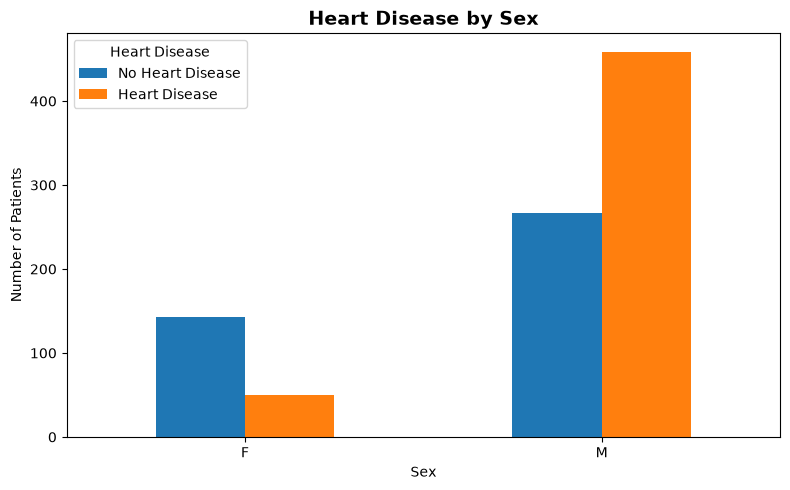

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/heart_disease_by_chestpaintype.png


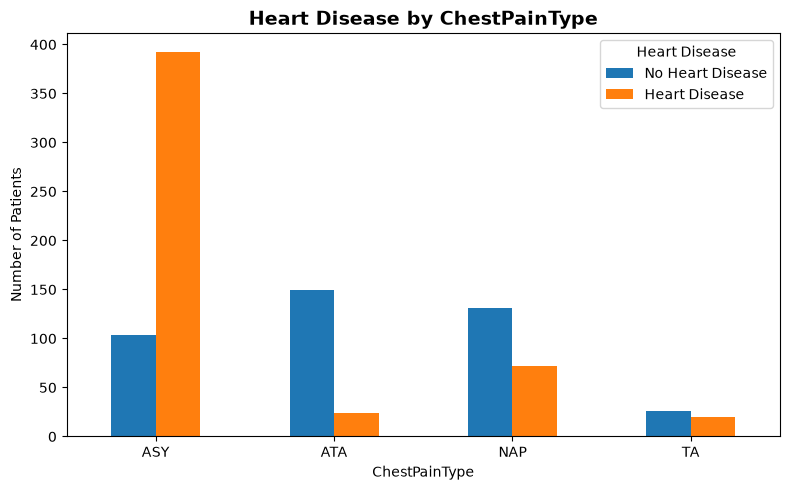

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/heart_disease_by_fastingbs.png


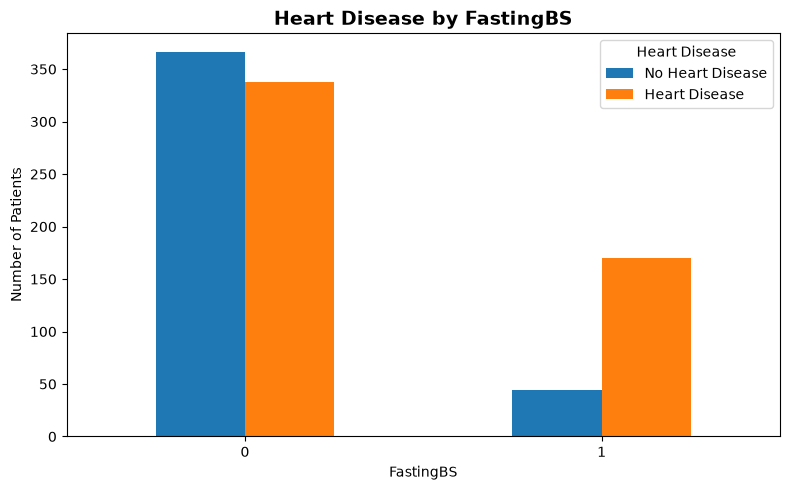

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/heart_disease_by_restingecg.png


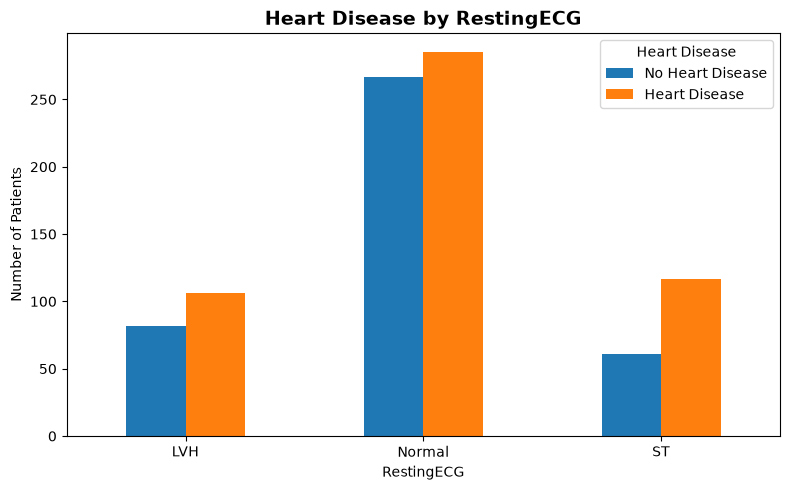

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/heart_disease_by_exerciseangina.png


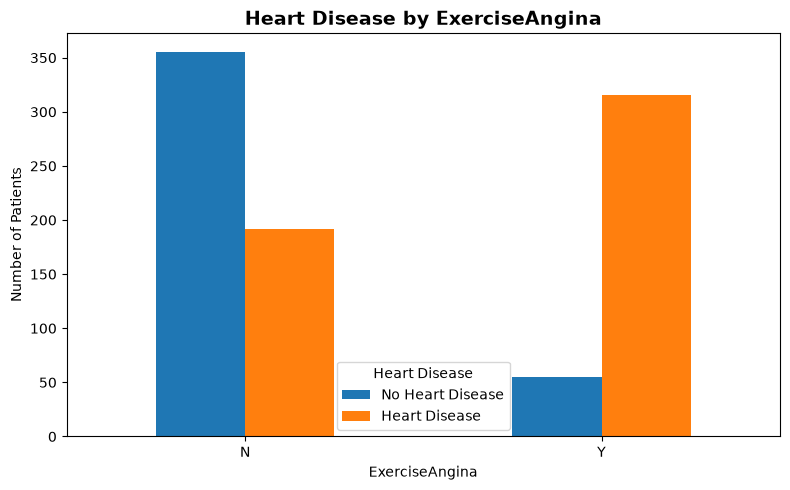

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/eda/heart_disease_by_st_slope.png


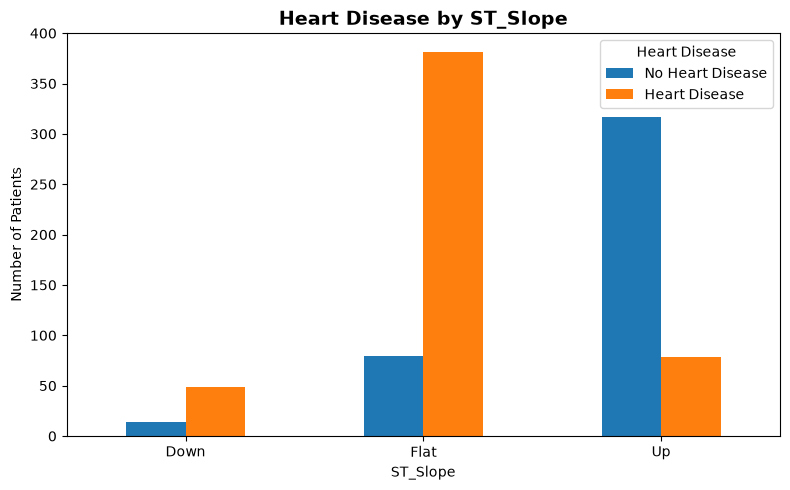

In [25]:
# ============================================================
# PHASE 5.6 — CATEGORICAL FEATURES VS HEART DISEASE
# ============================================================

categorical_eda_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for feature in categorical_eda_features:

    comparison = pd.crosstab(
        df_clean[feature],
        df_clean["HeartDisease"]
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    comparison.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(
        f"Heart Disease by {feature}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Patients")

    ax.legend(
        title="Heart Disease",
        labels=["No Heart Disease", "Heart Disease"]
    )

    plt.xticks(rotation=0)
    plt.tight_layout()

    save_chart(
        f"heart_disease_by_{feature.lower()}.png",
        "eda",
        fig
    )

    plt.show()

In [26]:
# ============================================================
# PHASE 5.7 — SAVE CATEGORICAL COMPARISON TABLES
# ============================================================

for feature in categorical_eda_features:

    comparison_table = pd.crosstab(
        df_clean[feature],
        df_clean["HeartDisease"]
    ).reset_index()

    comparison_table.columns = [
        feature,
        "No Heart Disease",
        "Heart Disease"
    ]

    save_table(
        comparison_table,
        f"{feature.lower()}_heart_disease_comparison.csv",
        index=False
    )

print("Categorical comparison tables saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/sex_heart_disease_comparison.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/chestpaintype_heart_disease_comparison.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/fastingbs_heart_disease_comparison.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/restingecg_heart_disease_comparison.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/exerciseangina_heart_disease_comparison.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/st_slope_heart_disease_comparison.csv
Categorical comparison tables saved successfully.


In [27]:
# ============================================================
# PHASE 5.8 — CATEGORICAL HEART DISEASE RATES
# ============================================================

categorical_rate_tables = []

for feature in categorical_eda_features:

    rate_table = (
        df_clean
        .groupby(feature)["HeartDisease"]
        .agg(
            Total_Patients="count",
            Heart_Disease_Cases="sum",
            Heart_Disease_Rate="mean"
        )
        .reset_index()
    )

    rate_table["Heart_Disease_Rate_Percentage"] = (
        rate_table["Heart_Disease_Rate"] * 100
    ).round(2)

    rate_table["Feature"] = feature

    categorical_rate_tables.append(rate_table)

# Combine all categorical summaries
categorical_disease_rates = pd.concat(
    categorical_rate_tables,
    ignore_index=True
)

display(categorical_disease_rates)

,Sex,Total_Patients,Heart_Disease_Cases,Heart_Disease_Rate,Heart_Disease_Rate_Percentage,Feature,ChestPainType,FastingBS,RestingECG,ExerciseAngina,ST_Slope
0,F,193,50,0.259067,25.91,Sex,NaN,NaN,NaN,NaN,NaN
1,M,725,458,0.631724,63.17,Sex,NaN,NaN,NaN,NaN,NaN
2,NaN,496,392,0.790323,79.03,ChestPainType,ASY,NaN,NaN,NaN,NaN
3,NaN,173,24,0.138728,13.87,ChestPainType,ATA,NaN,NaN,NaN,NaN
4,NaN,203,72,0.354680,35.47,ChestPainType,NAP,NaN,NaN,NaN,NaN
5,NaN,46,20,0.434783,43.48,ChestPainType,TA,NaN,NaN,NaN,NaN
6,NaN,704,338,0.480114,48.01,FastingBS,NaN,0.0,NaN,NaN,NaN
7,NaN,214,170,0.794393,79.44,FastingBS,NaN,1.0,NaN,NaN,NaN
8,NaN,188,106,0.563830,56.38,RestingECG,NaN,NaN,LVH,NaN,NaN
9,NaN,552,285,0.516304,51.63,RestingECG,NaN,NaN,Normal,NaN,NaN


In [28]:
# ============================================================
# PHASE 5.8 — CATEGORICAL HEART DISEASE RATES
# ============================================================

categorical_rate_tables = []

for feature in categorical_eda_features:

    rate_table = (
        df_clean
        .groupby(feature)["HeartDisease"]
        .agg(
            Total_Patients="count",
            Heart_Disease_Cases="sum",
            Heart_Disease_Rate="mean"
        )
        .reset_index()
    )

    # Rename the category column so every table has the same structure
    rate_table = rate_table.rename(
        columns={feature: "Category"}
    )

    # Add the original feature name
    rate_table["Feature"] = feature

    # Convert rate to percentage
    rate_table["Heart_Disease_Rate_Percentage"] = (
        rate_table["Heart_Disease_Rate"] * 100
    ).round(2)

    # Keep columns in a clean order
    rate_table = rate_table[
        [
            "Feature",
            "Category",
            "Total_Patients",
            "Heart_Disease_Cases",
            "Heart_Disease_Rate",
            "Heart_Disease_Rate_Percentage"
        ]
    ]

    categorical_rate_tables.append(rate_table)

# Combine all categorical summaries
categorical_disease_rates = pd.concat(
    categorical_rate_tables,
    ignore_index=True
)

display(categorical_disease_rates)

,Feature,Category,Total_Patients,Heart_Disease_Cases,Heart_Disease_Rate,Heart_Disease_Rate_Percentage
0,Sex,F,193,50,0.259067,25.91
1,Sex,M,725,458,0.631724,63.17
2,ChestPainType,ASY,496,392,0.790323,79.03
3,ChestPainType,ATA,173,24,0.138728,13.87
4,ChestPainType,NAP,203,72,0.354680,35.47
5,ChestPainType,TA,46,20,0.434783,43.48
6,FastingBS,0,704,338,0.480114,48.01
7,FastingBS,1,214,170,0.794393,79.44
8,RestingECG,LVH,188,106,0.563830,56.38
9,RestingECG,Normal,552,285,0.516304,51.63


In [29]:
save_table(
    categorical_disease_rates,
    "categorical_heart_disease_rates.csv",
    index=False
)

print("Categorical heart-disease rate summary saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/categorical_heart_disease_rates.csv
Categorical heart-disease rate summary saved successfully.


# PHASE 6 — DEFINE PREDICTORS AND TARGET

In [30]:
# ============================================================
# PHASE 6.1 — DEFINE PREDICTORS AND TARGET
# ============================================================

X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]

print("Predictors and target defined successfully.")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Predictors and target defined successfully.

X shape: (918, 11)
y shape: (918,)

Predictor columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

Target distribution:
HeartDisease
0    410
1    508
Name: count, dtype: int64


In [31]:
# ============================================================
# PHASE 7.1 — IMPORT TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("train_test_split imported successfully.")

train_test_split imported successfully.


In [32]:
# ============================================================
# PHASE 7.2 — 80/20 STRATIFIED TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train-test split completed successfully.")

print("\nTraining set:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTest set:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Train-test split completed successfully.

Training set:
X_train shape: (734, 11)
y_train shape: (734,)

Test set:
X_test shape: (184, 11)
y_test shape: (184,)


In [33]:
# ============================================================
# PHASE 7.3 — VERIFY CLASS DISTRIBUTION AFTER SPLIT
# ============================================================

split_distribution = pd.DataFrame({
    "Dataset": [
        "Training",
        "Training",
        "Testing",
        "Testing"
    ],
    "HeartDisease": [
        0,
        1,
        0,
        1
    ],
    "Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum(),
        (y_test == 0).sum(),
        (y_test == 1).sum()
    ]
})

split_distribution["Class Label"] = (
    split_distribution["HeartDisease"]
    .map({
        0: "No Heart Disease",
        1: "Heart Disease"
    })
)

split_distribution["Percentage Within Dataset"] = [
    round((y_train == 0).mean() * 100, 2),
    round((y_train == 1).mean() * 100, 2),
    round((y_test == 0).mean() * 100, 2),
    round((y_test == 1).mean() * 100, 2)
]

split_distribution = split_distribution[
    [
        "Dataset",
        "HeartDisease",
        "Class Label",
        "Count",
        "Percentage Within Dataset"
    ]
]

display(split_distribution)

,Dataset,HeartDisease,Class Label,Count,Percentage Within Dataset
0,Training,0,No Heart Disease,328,44.69
1,Training,1,Heart Disease,406,55.31
2,Testing,0,No Heart Disease,82,44.57
3,Testing,1,Heart Disease,102,55.43


In [34]:
# ============================================================
# PHASE 7.4 — SAVE TRAIN-TEST SPLIT SUMMARY
# ============================================================

save_table(
    split_distribution,
    "train_test_split_distribution.csv",
    index=False
)

print("Train-test split summary saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/train_test_split_distribution.csv
Train-test split summary saved successfully.


# PHASE 8 — DEFINE FEATURE GROUPS

In [35]:
# ============================================================
# PHASE 8.1 — DEFINE NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal predictors:", len(numerical_features) + len(categorical_features))

Numerical features:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

Categorical features:
['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Total predictors: 11


# PHASE 9 — PREPROCESSING PIPELINES

In [36]:
# ============================================================
# PHASE 9.1 — IMPORT PREPROCESSING TOOLS
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Preprocessing tools imported successfully.")

Preprocessing tools imported successfully.


In [37]:
# ============================================================
# PHASE 9.2 — DEFINE ONE-HOT ENCODER
# ============================================================

def create_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        # Compatibility with older scikit-learn versions
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )


print("OneHotEncoder function created successfully.")

OneHotEncoder function created successfully.


In [38]:
# ============================================================
# PHASE 9.3 — ANN / SVM PREPROCESSING
# ============================================================

# Numerical preprocessing for ANN and SVM
scaled_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
scaled_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            create_one_hot_encoder()
        )
    ]
)

# Combine numerical and categorical preprocessing
scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            scaled_numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            scaled_categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("ANN/SVM preprocessing pipeline created successfully.")

ANN/SVM preprocessing pipeline created successfully.


In [39]:
# ============================================================
# PHASE 9.4 — RANDOM FOREST / XGBOOST PREPROCESSING
# ============================================================

# Numerical preprocessing for tree-based models
tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# Categorical preprocessing
tree_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            create_one_hot_encoder()
        )
    ]
)

# Combine numerical and categorical preprocessing
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            tree_numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            tree_categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Random Forest/XGBoost preprocessing pipeline created successfully.")

Random Forest/XGBoost preprocessing pipeline created successfully.


# PHASE 10 — FEATURE ANALYSIS

In [40]:
# ============================================================
# PHASE 10.1 — NUMERICAL CORRELATION ANALYSIS
# TRAINING DATA ONLY
# ============================================================

# Combine training numerical features with the training target
correlation_data = X_train[numerical_features].copy()
correlation_data["HeartDisease"] = y_train

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

print("Numerical correlation matrix:")
display(correlation_matrix.round(3))

Numerical correlation matrix:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease
Age,1.000,0.259,0.033,-0.398,0.226,0.245
RestingBP,0.259,1.000,0.099,-0.121,0.152,0.102
Cholesterol,0.033,0.099,1.000,0.001,0.064,0.081
MaxHR,-0.398,-0.121,0.001,1.000,-0.146,-0.407
Oldpeak,0.226,0.152,0.064,-0.146,1.000,0.377
HeartDisease,0.245,0.102,0.081,-0.407,0.377,1.000


In [41]:
# ============================================================
# PHASE 10.2 — CORRELATION WITH TARGET
# ============================================================

correlation_scores = (
    correlation_matrix["HeartDisease"]
    .drop("HeartDisease")
    .sort_values(
        key=abs,
        ascending=False
    )
    .reset_index()
)

correlation_scores.columns = [
    "Feature",
    "Correlation_with_HeartDisease"
]

display(correlation_scores)

,Feature,Correlation_with_HeartDisease
0,MaxHR,-0.407227
1,Oldpeak,0.376603
2,Age,0.244689
3,RestingBP,0.102055
4,Cholesterol,0.081290


In [42]:
# ============================================================
# PHASE 10.5 — IMPORT CHI-SQUARE TEST
# ============================================================

from scipy.stats import chi2_contingency

print("Chi-square test imported successfully.")

Chi-square test imported successfully.


In [43]:
# ============================================================
# PHASE 10.6 — CHI-SQUARE ANALYSIS
# TRAINING DATA ONLY
# ============================================================

chi_square_results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(
        X_train[feature],
        y_train
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_square_results.append({
        "Feature": feature,
        "Chi_Square_Score": chi2,
        "P_Value": p_value,
        "Degrees_of_Freedom": dof
    })

chi_square_results = pd.DataFrame(
    chi_square_results
).sort_values(
    by="Chi_Square_Score",
    ascending=False
).reset_index(drop=True)

chi_square_results["Significant_at_0.05"] = (
    chi_square_results["P_Value"] < 0.05
)

display(chi_square_results)

,Feature,Chi_Square_Score,P_Value,Degrees_of_Freedom,Significant_at_0.05
0,ST_Slope,309.175273,7.302010e-68,2,True
1,ChestPainType,214.339359,3.359717e-46,3,True
2,ExerciseAngina,174.859118,6.426459e-40,1,True
3,Sex,56.263232,6.338981e-14,1,True
4,FastingBS,48.907227,2.683601e-12,1,True
5,RestingECG,9.768953,7.563080e-03,2,True


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/feature_analysis/chi_square_scores.png


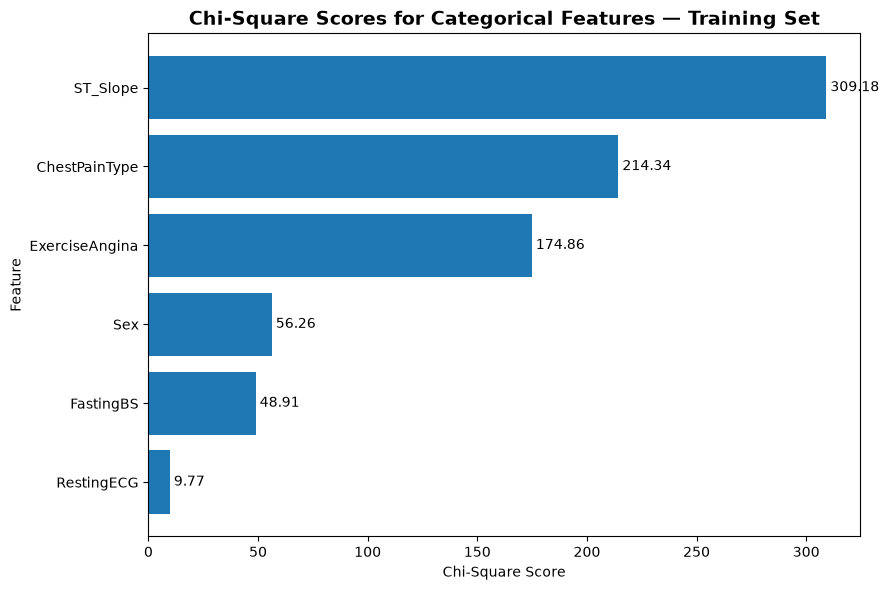

In [44]:
# ============================================================
# PHASE 10.7 — CHI-SQUARE SCORE CHART
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    chi_square_results["Feature"],
    chi_square_results["Chi_Square_Score"]
)

ax.set_title(
    "Chi-Square Scores for Categorical Features — Training Set",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Chi-Square Score")
ax.set_ylabel("Feature")

# Highest score at the top
ax.invert_yaxis()

# Add score labels
for bar, score in zip(
    bars,
    chi_square_results["Chi_Square_Score"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {score:.2f}",
        va="center"
    )

plt.tight_layout()

save_chart(
    "chi_square_scores.png",
    "feature_analysis",
    fig
)

plt.show()

In [45]:
# ============================================================
# PHASE 10.8 — SAVE CHI-SQUARE RESULTS
# ============================================================

save_table(
    chi_square_results,
    "chi_square_scores.csv",
    index=False
)

print("Chi-square analysis results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/chi_square_scores.csv
Chi-square analysis results saved successfully.


In [46]:
# ============================================================
# PHASE 10.9 — IMPORT MUTUAL INFORMATION TOOLS
# ============================================================

from sklearn.feature_selection import mutual_info_classif
from sklearn.base import clone

print("Mutual information tools imported successfully.")

Mutual information tools imported successfully.


In [47]:
# ============================================================
# PHASE 10.10 — PREPARE TRAINING DATA FOR MUTUAL INFORMATION
# ============================================================

# Clone the tree-based preprocessor so the original pipeline
# definition remains untouched
mi_preprocessor = clone(tree_preprocessor)

# Fit preprocessing using TRAINING DATA ONLY
X_train_mi = mi_preprocessor.fit_transform(X_train)

# Obtain transformed feature names
transformed_feature_names = (
    mi_preprocessor.get_feature_names_out()
)

# Remove ColumnTransformer prefixes for cleaner display
clean_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in transformed_feature_names
]

print("Training data transformed successfully.")
print("Original predictors:", X_train.shape[1])
print("Transformed features:", X_train_mi.shape[1])

print("\nTransformed feature names:")
print(clean_feature_names)

Training data transformed successfully.
Original predictors: 11
Transformed features: 21

Transformed feature names:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'FastingBS_0', 'FastingBS_1', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [48]:
# ============================================================
# PHASE 10.11 — MUTUAL INFORMATION ANALYSIS
# TRAINING DATA ONLY
# ============================================================

# Numerical transformed features are continuous.
# One-hot encoded features are discrete.
discrete_mask = np.array(
    [False] * len(numerical_features)
    +
    [True] * (
        X_train_mi.shape[1] - len(numerical_features)
    )
)

# Calculate mutual information scores
mi_scores = mutual_info_classif(
    X_train_mi,
    y_train,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE
)

# Create results table
mutual_information_results = pd.DataFrame({
    "Feature": clean_feature_names,
    "Mutual_Information_Score": mi_scores
})

# Rank features from highest to lowest
mutual_information_results = (
    mutual_information_results
    .sort_values(
        by="Mutual_Information_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(mutual_information_results)

,Feature,Mutual_Information_Score
0,ST_Slope_Up,0.226930
1,ST_Slope_Flat,0.173418
2,ChestPainType_ASY,0.140330
3,ExerciseAngina_N,0.129468
4,ExerciseAngina_Y,0.129468
5,Oldpeak,0.098556
6,MaxHR,0.091925
7,ChestPainType_ATA,0.083652
8,Cholesterol,0.061028
9,Sex_F,0.039738


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/feature_analysis/mutual_information_scores.png


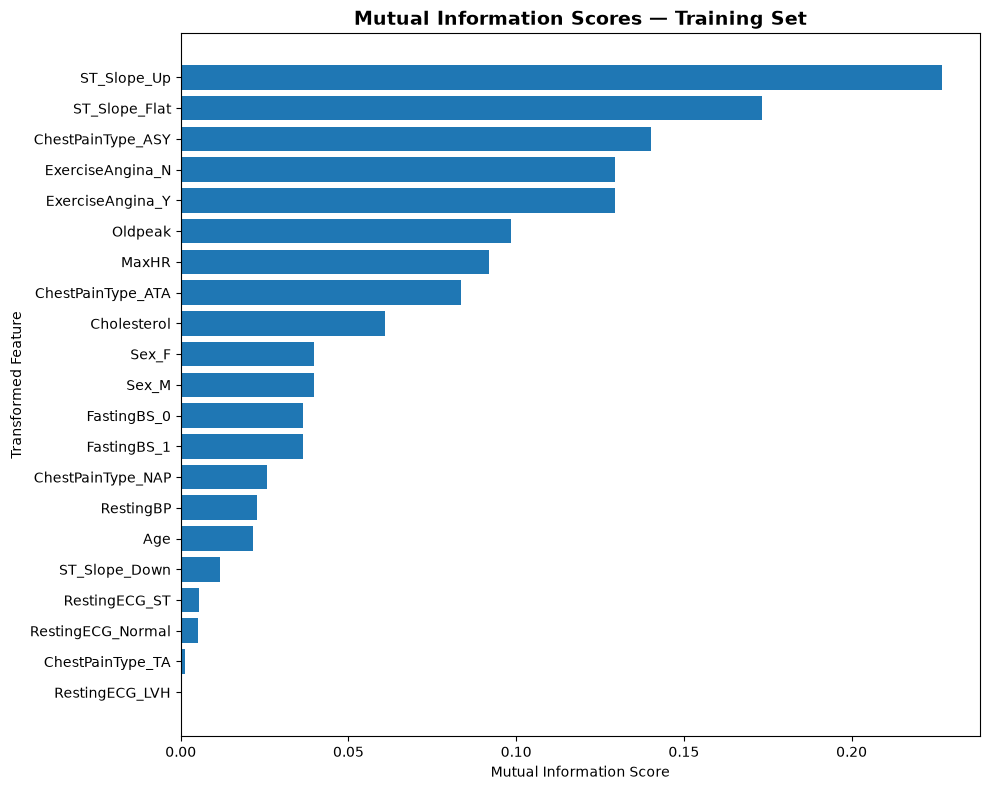

In [49]:
# ============================================================
# PHASE 10.12 — MUTUAL INFORMATION SCORE CHART
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

plot_data = mutual_information_results.sort_values(
    by="Mutual_Information_Score",
    ascending=True
)

ax.barh(
    plot_data["Feature"],
    plot_data["Mutual_Information_Score"]
)

ax.set_title(
    "Mutual Information Scores — Training Set",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Mutual Information Score")
ax.set_ylabel("Transformed Feature")

plt.tight_layout()

save_chart(
    "mutual_information_scores.png",
    "feature_analysis",
    fig
)

plt.show()

In [50]:
# ============================================================
# PHASE 10.13 — SAVE MUTUAL INFORMATION RESULTS
# ============================================================

save_table(
    mutual_information_results,
    "mutual_information_scores.csv",
    index=False
)

print("Mutual information analysis results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/mutual_information_scores.csv
Mutual information analysis results saved successfully.


# PHASE 11 — FEATURE SELECTION

In [51]:
# ============================================================
# PHASE 11.1 — IMPORT FEATURE SELECTION TOOLS
# ============================================================

from sklearn.feature_selection import SelectKBest

print("Feature selection tools imported successfully.")

Feature selection tools imported successfully.


In [52]:
# ============================================================
# PHASE 11.2 — DEFINE MUTUAL INFORMATION SCORE FUNCTION
# ============================================================

def mixed_mutual_information(X, y):

    # First 5 transformed features are numerical/continuous.
    # Remaining transformed features are one-hot encoded/discrete.
    discrete_features = np.array(
        [False] * len(numerical_features)
        +
        [True] * (X.shape[1] - len(numerical_features))
    )

    return mutual_info_classif(
        X,
        y,
        discrete_features=discrete_features,
        random_state=RANDOM_STATE
    )


print("Mutual information scoring function created successfully.")

Mutual information scoring function created successfully.


In [53]:
# ============================================================
# PHASE 11.3 — DEFINE FEATURE SELECTION CANDIDATES
# ============================================================

FEATURE_SELECTION_K_VALUES = [
    8,
    10,
    12,
    15,
    18,
    "all"
]

print("Candidate k values:")
print(FEATURE_SELECTION_K_VALUES)

Candidate k values:
[8, 10, 12, 15, 18, 'all']


In [54]:
# ============================================================
# PHASE 11.4 — CREATE FEATURE SELECTOR
# ============================================================

feature_selector = SelectKBest(
    score_func=mixed_mutual_information,
    k="all"
)

print("SelectKBest feature selector created successfully.")

SelectKBest feature selector created successfully.


# PHASE 12 — MODEL PIPELINE CONSTRUCTION

In [55]:
# ============================================================
# PHASE 12.1 — IMPORT CLASSIFICATION MODELS
# ============================================================

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

print("ANN, SVM and Random Forest imported successfully.")

ANN, SVM and Random Forest imported successfully.


In [56]:
# ============================================================
# PHASE 12.2 — IMPORT XGBOOST
# ============================================================

from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [57]:
# ============================================================
# PHASE 12.3 — BUILD ANN PIPELINE
# ============================================================

ann_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(scaled_preprocessor)
        ),
        (
            "feature_selection",
            SelectKBest(
                score_func=mixed_mutual_information,
                k="all"
            )
        ),
        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(100,),
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("ANN pipeline created successfully.")

ANN pipeline created successfully.


In [58]:
# ============================================================
# PHASE 12.4 — BUILD SVM PIPELINE
# ============================================================

svm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(scaled_preprocessor)
        ),
        (
            "feature_selection",
            SelectKBest(
                score_func=mixed_mutual_information,
                k="all"
            )
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=1.0,
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("SVM pipeline created successfully.")

SVM pipeline created successfully.


In [59]:
# ============================================================
# PHASE 12.5 — BUILD RANDOM FOREST PIPELINE
# ============================================================

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor)
        ),
        (
            "feature_selection",
            SelectKBest(
                score_func=mixed_mutual_information,
                k="all"
            )
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [60]:
# ============================================================
# PHASE 12.6 — BUILD XGBOOST PIPELINE
# ============================================================

xgboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor)
        ),
        (
            "feature_selection",
            SelectKBest(
                score_func=mixed_mutual_information,
                k="all"
            )
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=1.0,
                colsample_bytree=1.0,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [61]:
# ============================================================
# PHASE 12.7 — STORE MODEL PIPELINES
# ============================================================

model_pipelines = {
    "ANN": ann_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline
}

print("Model pipelines prepared:")

for model_name in model_pipelines:
    print("-", model_name)

Model pipelines prepared:
- ANN
- SVM
- Random Forest
- XGBoost


In [62]:
# ============================================================
# PHASE 13.1 — IMPORT CROSS-VALIDATION AND METRIC TOOLS
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Cross-validation and evaluation tools imported successfully.")

Cross-validation and evaluation tools imported successfully.


In [63]:
# ============================================================
# PHASE 13.2 — DEFINE 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-fold StratifiedKFold created successfully.")

5-fold StratifiedKFold created successfully.


In [64]:
# ============================================================
# PHASE 13.3 — DEFINE BASELINE EVALUATION METRICS
# ============================================================

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "specificity": make_scorer(
        recall_score,
        pos_label=0,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc"
}

print("Evaluation metrics defined successfully.")

print("\nMetrics:")
for metric in scoring:
    print("-", metric)

Evaluation metrics defined successfully.

Metrics:
- accuracy
- precision
- recall
- specificity
- f1
- roc_auc


In [65]:
# ============================================================
# PHASE 13.4 — RUN BASELINE 5-FOLD CROSS-VALIDATION
# TRAINING DATA ONLY
# ============================================================

baseline_cv_records = []

for model_name, pipeline in model_pipelines.items():

    print(f"Evaluating {model_name}...")

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    baseline_cv_records.append({
        "Model": model_name,

        "Accuracy": cv_results["test_accuracy"].mean(),
        "Accuracy_STD": cv_results["test_accuracy"].std(),

        "Precision": cv_results["test_precision"].mean(),
        "Precision_STD": cv_results["test_precision"].std(),

        "Recall": cv_results["test_recall"].mean(),
        "Recall_STD": cv_results["test_recall"].std(),

        "Specificity": cv_results["test_specificity"].mean(),
        "Specificity_STD": cv_results["test_specificity"].std(),

        "F1": cv_results["test_f1"].mean(),
        "F1_STD": cv_results["test_f1"].std(),

        "ROC_AUC": cv_results["test_roc_auc"].mean(),
        "ROC_AUC_STD": cv_results["test_roc_auc"].std()
    })

    print(f"{model_name} completed.\n")


baseline_cv_results = pd.DataFrame(
    baseline_cv_records
)

display(
    baseline_cv_results.round(4)
)

Evaluating ANN...
ANN completed.

Evaluating SVM...
SVM completed.

Evaluating Random Forest...
Random Forest completed.

Evaluating XGBoost...
XGBoost completed.



,Model,Accuracy,Accuracy_STD,Precision,Precision_STD,Recall,Recall_STD,Specificity,Specificity_STD,F1,F1_STD,ROC_AUC,ROC_AUC_STD
0,ANN,0.8038,0.0239,0.8345,0.0431,0.8105,0.0370,0.7960,0.0740,0.8207,0.0180,0.8763,0.0282
1,SVM,0.8543,0.0378,0.8501,0.0497,0.8991,0.0207,0.7989,0.0829,0.8730,0.0285,0.9179,0.0319
2,Random Forest,0.8611,0.0314,0.8597,0.0429,0.8991,0.0422,0.8141,0.0712,0.8775,0.0261,0.9292,0.0256
3,XGBoost,0.8570,0.0176,0.8732,0.0300,0.8696,0.0292,0.8415,0.0465,0.8706,0.0149,0.9269,0.0223


In [66]:
# ============================================================
# PHASE 13.5 — SAVE BASELINE CROSS-VALIDATION RESULTS
# ============================================================

save_table(
    baseline_cv_results,
    "baseline_cv_results.csv",
    index=False
)

print("Baseline cross-validation results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/baseline_cv_results.csv
Baseline cross-validation results saved successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_performance/baseline_cv_comparison.png


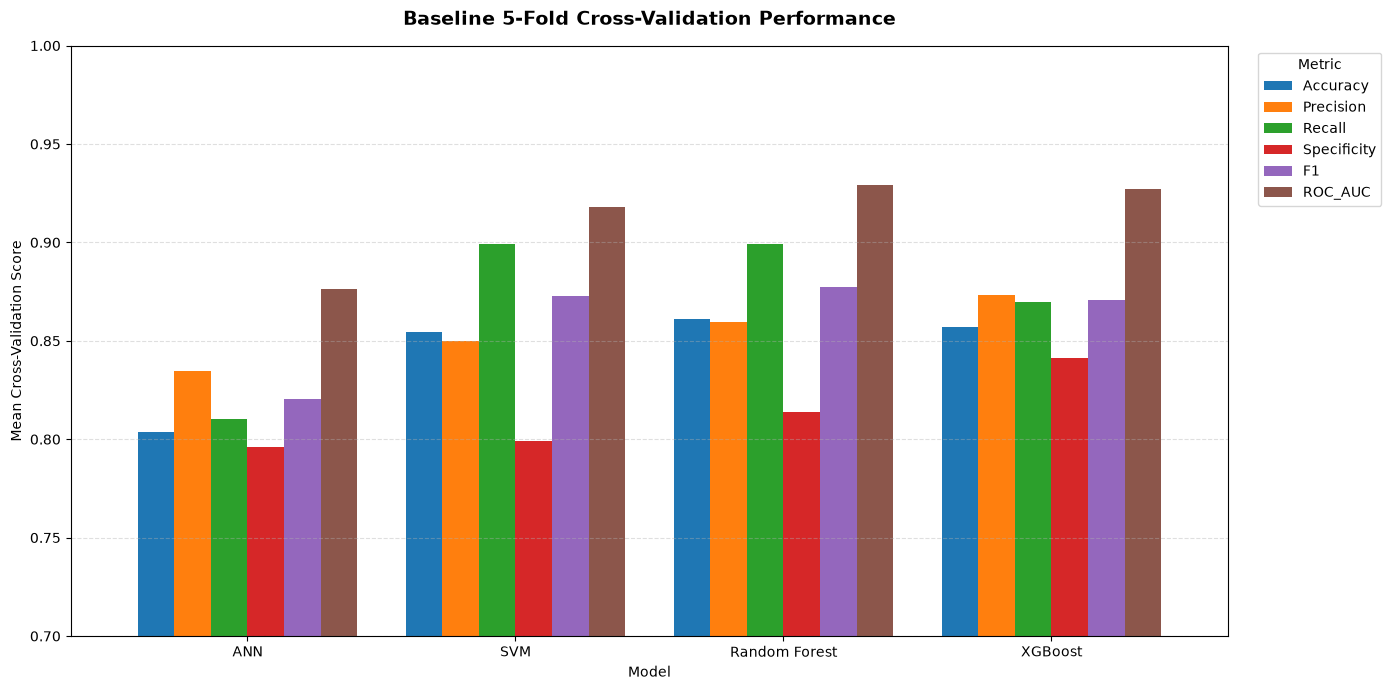

In [67]:
# ============================================================
# PHASE 13.6 — BASELINE MODEL COMPARISON CHART
# ============================================================

baseline_metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC_AUC"
]

baseline_chart_data = baseline_cv_results[
    ["Model"] + baseline_metrics_to_plot
].copy()

baseline_chart_data = baseline_chart_data.set_index("Model")

ax = baseline_chart_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82
)

plt.title(
    "Baseline 5-Fold Cross-Validation Performance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Model")
plt.ylabel("Mean Cross-Validation Score")

plt.ylim(0.70, 1.00)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

save_chart(
    "baseline_cv_comparison.png",
    "model_performance"
)

plt.show()

# PHASE 14 — TRAINING VS CROSS-VALIDATION ANALYSIS

In [68]:
# ============================================================
# PHASE 14.1 — CALCULATE TRAINING VS CV PERFORMANCE
# TRAINING DATA ONLY
# ============================================================

training_vs_cv_records = []

for model_name, pipeline in model_pipelines.items():

    print(f"Analysing {model_name}...")

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    training_vs_cv_records.append({
        "Model": model_name,

        "Train_Accuracy": cv_results["train_accuracy"].mean(),
        "CV_Accuracy": cv_results["test_accuracy"].mean(),

        "Train_Precision": cv_results["train_precision"].mean(),
        "CV_Precision": cv_results["test_precision"].mean(),

        "Train_Recall": cv_results["train_recall"].mean(),
        "CV_Recall": cv_results["test_recall"].mean(),

        "Train_Specificity": cv_results["train_specificity"].mean(),
        "CV_Specificity": cv_results["test_specificity"].mean(),

        "Train_F1": cv_results["train_f1"].mean(),
        "CV_F1": cv_results["test_f1"].mean(),

        "Train_ROC_AUC": cv_results["train_roc_auc"].mean(),
        "CV_ROC_AUC": cv_results["test_roc_auc"].mean()
    })

    print(f"{model_name} completed.\n")


training_vs_cv_results = pd.DataFrame(
    training_vs_cv_records
)

display(
    training_vs_cv_results.round(4)
)

Analysing ANN...
ANN completed.

Analysing SVM...
SVM completed.

Analysing Random Forest...
Random Forest completed.

Analysing XGBoost...
XGBoost completed.



,Model,Train_Accuracy,CV_Accuracy,Train_Precision,CV_Precision,Train_Recall,CV_Recall,Train_Specificity,CV_Specificity,Train_F1,CV_F1,Train_ROC_AUC,CV_ROC_AUC
0,ANN,0.9993,0.8038,0.9994,0.8345,0.9994,0.8105,0.9992,0.7960,0.9994,0.8207,1.0000,0.8763
1,SVM,0.8965,0.8543,0.8920,0.8501,0.9249,0.8991,0.8613,0.7989,0.9081,0.8730,0.9614,0.9179
2,Random Forest,1.0000,0.8611,1.0000,0.8597,1.0000,0.8991,1.0000,0.8141,1.0000,0.8775,1.0000,0.9292
3,XGBoost,0.9608,0.8570,0.9570,0.8732,0.9729,0.8696,0.9459,0.8415,0.9649,0.8706,0.9933,0.9269


In [69]:
# ============================================================
# PHASE 14.2 — CALCULATE GENERALISATION GAPS
# ============================================================

generalisation_gap_results = training_vs_cv_results.copy()

generalisation_gap_results["Accuracy_Gap"] = (
    generalisation_gap_results["Train_Accuracy"]
    - generalisation_gap_results["CV_Accuracy"]
)

generalisation_gap_results["Precision_Gap"] = (
    generalisation_gap_results["Train_Precision"]
    - generalisation_gap_results["CV_Precision"]
)

generalisation_gap_results["Recall_Gap"] = (
    generalisation_gap_results["Train_Recall"]
    - generalisation_gap_results["CV_Recall"]
)

generalisation_gap_results["Specificity_Gap"] = (
    generalisation_gap_results["Train_Specificity"]
    - generalisation_gap_results["CV_Specificity"]
)

generalisation_gap_results["F1_Gap"] = (
    generalisation_gap_results["Train_F1"]
    - generalisation_gap_results["CV_F1"]
)

generalisation_gap_results["ROC_AUC_Gap"] = (
    generalisation_gap_results["Train_ROC_AUC"]
    - generalisation_gap_results["CV_ROC_AUC"]
)

gap_columns = [
    "Model",
    "Accuracy_Gap",
    "Precision_Gap",
    "Recall_Gap",
    "Specificity_Gap",
    "F1_Gap",
    "ROC_AUC_Gap"
]

display(
    generalisation_gap_results[gap_columns].round(4)
)

,Model,Accuracy_Gap,Precision_Gap,Recall_Gap,Specificity_Gap,F1_Gap,ROC_AUC_Gap
0,ANN,0.1955,0.1649,0.1889,0.2032,0.1787,0.1237
1,SVM,0.0422,0.0419,0.0258,0.0624,0.0351,0.0435
2,Random Forest,0.1389,0.1403,0.1009,0.1859,0.1225,0.0708
3,XGBoost,0.1039,0.0838,0.1033,0.1044,0.0943,0.0663


In [70]:
# ============================================================
# PHASE 14.3 — SAVE TRAINING VS CV RESULTS
# ============================================================

save_table(
    training_vs_cv_results,
    "training_vs_cv_results.csv",
    index=False
)

save_table(
    generalisation_gap_results[gap_columns],
    "generalisation_gap_results.csv",
    index=False
)

print("Training vs CV analysis results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/training_vs_cv_results.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/generalisation_gap_results.csv
Training vs CV analysis results saved successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_performance/training_vs_cv_comparison.png


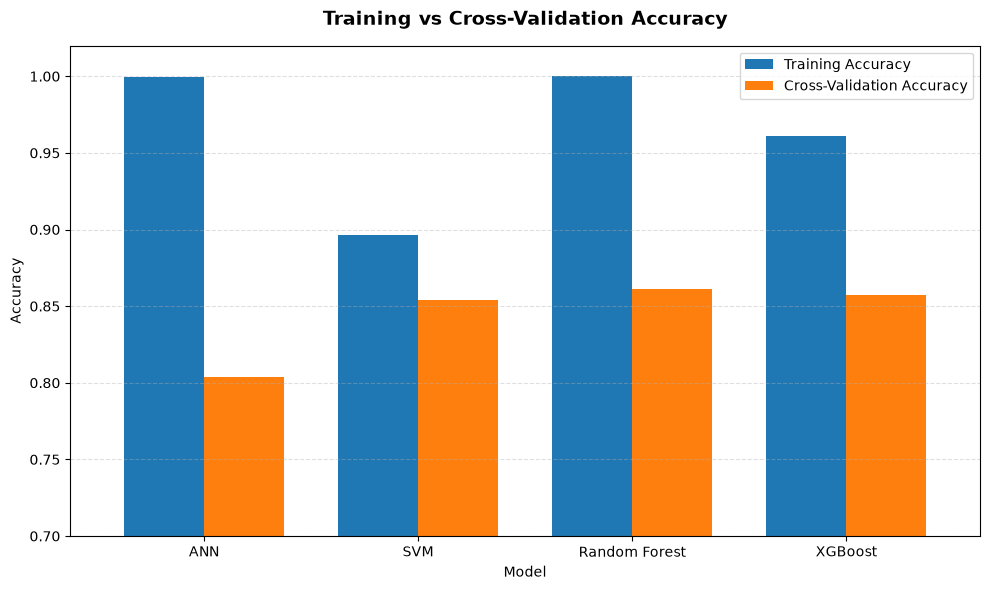

In [71]:
# ============================================================
# PHASE 14.4 — TRAINING VS CV ACCURACY CHART
# ============================================================

accuracy_comparison = training_vs_cv_results[
    [
        "Model",
        "Train_Accuracy",
        "CV_Accuracy"
    ]
].copy()

accuracy_comparison = accuracy_comparison.set_index("Model")

ax = accuracy_comparison.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title(
    "Training vs Cross-Validation Accuracy",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.70, 1.02)
plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    ["Training Accuracy", "Cross-Validation Accuracy"]
)

plt.tight_layout()

save_chart(
    "training_vs_cv_comparison.png",
    "model_performance"
)

plt.show()

# PHASE 15 — HYPERPARAMETER OPTIMISATION

## PHASE 15.1 — ANN HYPERPARAMETER OPTIMISATION

In [72]:
# ============================================================
# PHASE 15.1.1 — IMPORT HYPERPARAMETER SEARCH TOOL
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

print("RandomizedSearchCV imported successfully.")

RandomizedSearchCV imported successfully.


In [73]:
# ============================================================
# PHASE 15.1.2 — DEFINE ANN HYPERPARAMETER SEARCH SPACE
# ============================================================

ann_param_distributions = {

    # Feature selection
    "feature_selection__k": FEATURE_SELECTION_K_VALUES,

    # ANN architecture
    "classifier__hidden_layer_sizes": [
        (32,),
        (64,),
        (100,),
        (64, 32),
        (100, 50)
    ],

    # Activation function
    "classifier__activation": [
        "relu",
        "tanh"
    ],

    # L2 regularisation
    "classifier__alpha": [
        0.0001,
        0.001,
        0.01,
        0.1
    ],

    # Learning rate
    "classifier__learning_rate_init": [
        0.0005,
        0.001,
        0.005,
        0.01
    ],

    # Early stopping can help reduce overfitting
    "classifier__early_stopping": [
        True
    ]
}

print("ANN hyperparameter search space created successfully.")

for parameter, values in ann_param_distributions.items():
    print(f"\n{parameter}:")
    print(values)

ANN hyperparameter search space created successfully.

feature_selection__k:
[8, 10, 12, 15, 18, 'all']

classifier__hidden_layer_sizes:
[(32,), (64,), (100,), (64, 32), (100, 50)]

classifier__activation:
['relu', 'tanh']

classifier__alpha:
[0.0001, 0.001, 0.01, 0.1]

classifier__learning_rate_init:
[0.0005, 0.001, 0.005, 0.01]

classifier__early_stopping:
[True]


In [74]:
# ============================================================
# PHASE 15.1.3 — CREATE ANN RANDOMIZED SEARCH
# ============================================================

ann_random_search = RandomizedSearchCV(
    estimator=ann_pipeline,
    param_distributions=ann_param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True
)

print("ANN RandomizedSearchCV created successfully.")

ANN RandomizedSearchCV created successfully.


In [75]:
# ============================================================
# PHASE 15.1.4 — RUN ANN HYPERPARAMETER OPTIMISATION
# TRAINING DATA ONLY
# ============================================================

print("Starting ANN hyperparameter optimisation...")

ann_random_search.fit(
    X_train,
    y_train
)

print("\nANN hyperparameter optimisation completed.")

print("\nBest CV ROC-AUC:")
print(round(ann_random_search.best_score_, 4))

print("\nBest parameters:")

for parameter, value in ann_random_search.best_params_.items():
    print(f"{parameter}: {value}")

Starting ANN hyperparameter optimisation...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

ANN hyperparameter optimisation completed.

Best CV ROC-AUC:
0.9214

Best parameters:
feature_selection__k: 15
classifier__learning_rate_init: 0.01
classifier__hidden_layer_sizes: (32,)
classifier__early_stopping: True
classifier__alpha: 0.01
classifier__activation: relu


In [76]:
# ============================================================
# PHASE 15.1.5 — ANN TUNING RESULTS
# ============================================================

ann_search_results = pd.DataFrame(
    ann_random_search.cv_results_
)

ann_top_results = (
    ann_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_feature_selection__k",
            "param_classifier__hidden_layer_sizes",
            "param_classifier__activation",
            "param_classifier__alpha",
            "param_classifier__learning_rate_init",
            "param_classifier__early_stopping"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

ann_top_results = ann_top_results.rename(
    columns={
        "rank_test_score": "Rank",
        "mean_test_score": "Mean_CV_ROC_AUC",
        "std_test_score": "CV_ROC_AUC_STD",
        "mean_train_score": "Mean_Train_ROC_AUC",
        "param_feature_selection__k": "Selected_k",
        "param_classifier__hidden_layer_sizes": "Hidden_Layers",
        "param_classifier__activation": "Activation",
        "param_classifier__alpha": "Alpha",
        "param_classifier__learning_rate_init": "Learning_Rate",
        "param_classifier__early_stopping": "Early_Stopping"
    }
)

display(ann_top_results)

,Rank,Mean_CV_ROC_AUC,CV_ROC_AUC_STD,Mean_Train_ROC_AUC,Selected_k,Hidden_Layers,Activation,Alpha,Learning_Rate,Early_Stopping
0,1,0.921444,0.029721,0.927977,15,"(32,)",relu,0.0100,0.010,True
1,2,0.919220,0.027682,0.936203,all,"(64, 32)",relu,0.0010,0.010,True
2,3,0.915762,0.033433,0.947855,15,"(100, 50)",relu,0.1000,0.010,True
3,4,0.914347,0.034584,0.921649,12,"(64, 32)",relu,0.0001,0.005,True
4,5,0.913200,0.038296,0.915391,12,"(100,)",tanh,0.1000,0.010,True
5,6,0.912891,0.037469,0.915710,12,"(100, 50)",tanh,0.0100,0.010,True
6,7,0.910702,0.040522,0.915563,12,"(100,)",tanh,0.0001,0.005,True
7,8,0.910207,0.035375,0.913288,12,"(64,)",tanh,0.1000,0.005,True
8,9,0.909691,0.028658,0.916396,12,"(100, 50)",relu,0.0100,0.005,True
9,10,0.909103,0.047307,0.931300,18,"(64, 32)",relu,0.0100,0.010,True


In [77]:
# ============================================================
# PHASE 15.1.6 — SAVE ANN TUNING RESULTS
# ============================================================

save_table(
    ann_top_results,
    "ann_top_tuning_results.csv",
    index=False
)

ann_best_summary = pd.DataFrame({
    "Item": [
        "Best CV ROC-AUC",
        "Selected k",
        "Hidden Layers",
        "Activation",
        "Alpha",
        "Learning Rate",
        "Early Stopping"
    ],
    "Value": [
        ann_random_search.best_score_,
        ann_random_search.best_params_["feature_selection__k"],
        str(ann_random_search.best_params_[
            "classifier__hidden_layer_sizes"
        ]),
        ann_random_search.best_params_["classifier__activation"],
        ann_random_search.best_params_["classifier__alpha"],
        ann_random_search.best_params_["classifier__learning_rate_init"],
        ann_random_search.best_params_["classifier__early_stopping"]
    ]
})

display(ann_best_summary)

save_table(
    ann_best_summary,
    "ann_best_configuration.csv",
    index=False
)

print("ANN tuning results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/ann_top_tuning_results.csv


,Item,Value
0,Best CV ROC-AUC,0.921444
1,Selected k,15
2,Hidden Layers,"(32,)"
3,Activation,relu
4,Alpha,0.01
5,Learning Rate,0.01
6,Early Stopping,True


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/ann_best_configuration.csv
ANN tuning results saved successfully.


## PHASE 15.2 — SVM HYPERPARAMETER OPTIMISATION

In [78]:
# ============================================================
# PHASE 15.2.1 — DEFINE SVM HYPERPARAMETER SEARCH SPACE
# ============================================================

svm_param_distributions = {

    # Feature selection
    "feature_selection__k": FEATURE_SELECTION_K_VALUES,

    # Regularisation strength
    "classifier__C": [
        0.1,
        0.5,
        1,
        2,
        5,
        10,
        20,
        50
    ],

    # Kernel coefficient
    "classifier__gamma": [
        "scale",
        "auto",
        0.001,
        0.01,
        0.1,
        1
    ],

    # Kernel type
    "classifier__kernel": [
        "rbf",
        "linear",
        "poly"
    ],

    # Class weighting
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

print("SVM hyperparameter search space created successfully.")

for parameter, values in svm_param_distributions.items():
    print(f"\n{parameter}:")
    print(values)

SVM hyperparameter search space created successfully.

feature_selection__k:
[8, 10, 12, 15, 18, 'all']

classifier__C:
[0.1, 0.5, 1, 2, 5, 10, 20, 50]

classifier__gamma:
['scale', 'auto', 0.001, 0.01, 0.1, 1]

classifier__kernel:
['rbf', 'linear', 'poly']

classifier__class_weight:
[None, 'balanced']


In [79]:
# ============================================================
# PHASE 15.2.2 — CREATE SVM RANDOMIZED SEARCH
# ============================================================

svm_random_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_distributions,
    n_iter=25,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True
)

print("SVM RandomizedSearchCV created successfully.")

SVM RandomizedSearchCV created successfully.


In [80]:
# ============================================================
# PHASE 15.2.3 — RUN SVM HYPERPARAMETER OPTIMISATION
# TRAINING DATA ONLY
# ============================================================

print("Starting SVM hyperparameter optimisation...")

svm_random_search.fit(
    X_train,
    y_train
)

print("\nSVM hyperparameter optimisation completed.")

print("\nBest CV ROC-AUC:")
print(round(svm_random_search.best_score_, 4))

print("\nBest parameters:")
for parameter, value in svm_random_search.best_params_.items():
    print(f"{parameter}: {value}")

Starting SVM hyperparameter optimisation...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

SVM hyperparameter optimisation completed.

Best CV ROC-AUC:
0.9197

Best parameters:
feature_selection__k: all
classifier__kernel: poly
classifier__gamma: 0.1
classifier__class_weight: balanced
classifier__C: 0.5


In [82]:
# ============================================================
# PHASE 15.2.4 — SVM TUNING RESULTS
# ============================================================

svm_search_results = pd.DataFrame(
    svm_random_search.cv_results_
)

svm_top_results = (
    svm_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_feature_selection__k",
            "param_classifier__C",
            "param_classifier__gamma",
            "param_classifier__kernel",
            "param_classifier__class_weight"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

svm_top_results = svm_top_results.rename(
    columns={
        "rank_test_score": "Rank",
        "mean_test_score": "Mean_CV_ROC_AUC",
        "std_test_score": "CV_ROC_AUC_STD",
        "mean_train_score": "Mean_Train_ROC_AUC",
        "param_feature_selection__k": "Selected_k",
        "param_classifier__C": "C",
        "param_classifier__gamma": "Gamma",
        "param_classifier__kernel": "Kernel",
        "param_classifier__class_weight": "Class_Weight"
    }
)

display(svm_top_results)

,Rank,Mean_CV_ROC_AUC,CV_ROC_AUC_STD,Mean_Train_ROC_AUC,Selected_k,C,Gamma,Kernel,Class_Weight
0,1,0.919704,0.027718,0.961547,all,0.5,0.1,poly,balanced
1,2,0.919692,0.032658,0.925744,all,50.0,auto,linear,balanced
2,3,0.918940,0.030861,0.926047,all,0.5,0.001,linear,balanced
3,4,0.918276,0.035870,0.926092,18,0.5,0.1,linear,NaN
4,5,0.918196,0.037207,0.929538,12,0.5,auto,rbf,balanced
5,6,0.917949,0.029692,0.960119,18,1.0,0.1,poly,balanced
6,7,0.916399,0.037108,0.923810,18,5.0,1,linear,NaN
7,8,0.916215,0.034838,0.924608,all,1.0,0.01,rbf,balanced
8,9,0.914837,0.041052,0.920060,12,1.0,scale,linear,balanced
9,10,0.913486,0.039852,0.920886,12,2.0,scale,linear,balanced


In [83]:
# ============================================================
# PHASE 15.2.5 — SAVE SVM TUNING RESULTS
# ============================================================

save_table(
    svm_top_results,
    "svm_top_tuning_results.csv",
    index=False
)

svm_best_summary = pd.DataFrame({
    "Item": [
        "Best CV ROC-AUC",
        "Selected k",
        "C",
        "Gamma",
        "Kernel",
        "Class Weight"
    ],
    "Value": [
        svm_random_search.best_score_,
        svm_random_search.best_params_["feature_selection__k"],
        svm_random_search.best_params_["classifier__C"],
        svm_random_search.best_params_["classifier__gamma"],
        svm_random_search.best_params_["classifier__kernel"],
        svm_random_search.best_params_["classifier__class_weight"]
    ]
})

display(svm_best_summary)

save_table(
    svm_best_summary,
    "svm_best_configuration.csv",
    index=False
)

print("SVM tuning results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/svm_top_tuning_results.csv


,Item,Value
0,Best CV ROC-AUC,0.919704
1,Selected k,all
2,C,0.5
3,Gamma,0.1
4,Kernel,poly
5,Class Weight,balanced


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/svm_best_configuration.csv
SVM tuning results saved successfully.


## PHASE 15.3 — RANDOM FOREST HYPERPARAMETER OPTIMISATION

In [84]:
# ============================================================
# PHASE 15.3.1 — DEFINE RANDOM FOREST SEARCH SPACE
# ============================================================

random_forest_param_distributions = {

    # Feature selection
    "feature_selection__k": FEATURE_SELECTION_K_VALUES,

    # Number of trees
    "classifier__n_estimators": [
        200,
        300,
        500,
        700
    ],

    # Tree depth
    "classifier__max_depth": [
        None,
        5,
        10,
        15,
        20
    ],

    # Minimum samples required to split
    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    # Minimum samples required at leaf
    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ],

    # Number of features considered per split
    "classifier__max_features": [
        "sqrt",
        "log2",
        None
    ],

    # Class weighting
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

print("Random Forest hyperparameter search space created successfully.")

for parameter, values in random_forest_param_distributions.items():
    print(f"\n{parameter}:")
    print(values)

Random Forest hyperparameter search space created successfully.

feature_selection__k:
[8, 10, 12, 15, 18, 'all']

classifier__n_estimators:
[200, 300, 500, 700]

classifier__max_depth:
[None, 5, 10, 15, 20]

classifier__min_samples_split:
[2, 5, 10]

classifier__min_samples_leaf:
[1, 2, 4]

classifier__max_features:
['sqrt', 'log2', None]

classifier__class_weight:
[None, 'balanced']


In [85]:
# ============================================================
# PHASE 15.3.2 — CREATE RANDOM FOREST RANDOMIZED SEARCH
# ============================================================

random_forest_random_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True
)

print("Random Forest RandomizedSearchCV created successfully.")

Random Forest RandomizedSearchCV created successfully.


In [86]:
# ============================================================
# PHASE 15.3.3 — RUN RANDOM FOREST HYPERPARAMETER OPTIMISATION
# TRAINING DATA ONLY
# ============================================================

print("Starting Random Forest hyperparameter optimisation...")

random_forest_random_search.fit(
    X_train,
    y_train
)

print("\nRandom Forest hyperparameter optimisation completed.")

print("\nBest CV ROC-AUC:")
print(
    round(
        random_forest_random_search.best_score_,
        4
    )
)

print("\nBest parameters:")

for parameter, value in random_forest_random_search.best_params_.items():
    print(f"{parameter}: {value}")

Starting Random Forest hyperparameter optimisation...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Random Forest hyperparameter optimisation completed.

Best CV ROC-AUC:
0.9333

Best parameters:
feature_selection__k: 15
classifier__n_estimators: 500
classifier__min_samples_split: 5
classifier__min_samples_leaf: 4
classifier__max_features: log2
classifier__max_depth: 20
classifier__class_weight: balanced


In [87]:
# ============================================================
# PHASE 15.3.4 — RANDOM FOREST TUNING RESULTS
# ============================================================

random_forest_search_results = pd.DataFrame(
    random_forest_random_search.cv_results_
)

random_forest_top_results = (
    random_forest_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_feature_selection__k",
            "param_classifier__n_estimators",
            "param_classifier__max_depth",
            "param_classifier__min_samples_split",
            "param_classifier__min_samples_leaf",
            "param_classifier__max_features",
            "param_classifier__class_weight"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

random_forest_top_results = random_forest_top_results.rename(
    columns={
        "rank_test_score": "Rank",
        "mean_test_score": "Mean_CV_ROC_AUC",
        "std_test_score": "CV_ROC_AUC_STD",
        "mean_train_score": "Mean_Train_ROC_AUC",
        "param_feature_selection__k": "Selected_k",
        "param_classifier__n_estimators": "N_Estimators",
        "param_classifier__max_depth": "Max_Depth",
        "param_classifier__min_samples_split": "Min_Samples_Split",
        "param_classifier__min_samples_leaf": "Min_Samples_Leaf",
        "param_classifier__max_features": "Max_Features",
        "param_classifier__class_weight": "Class_Weight"
    }
)

display(random_forest_top_results)

,Rank,Mean_CV_ROC_AUC,CV_ROC_AUC_STD,Mean_Train_ROC_AUC,Selected_k,N_Estimators,Max_Depth,Min_Samples_Split,Min_Samples_Leaf,Max_Features,Class_Weight
0,1,0.933267,0.023737,0.975872,15,500,20,5,4,log2,balanced
1,2,0.932289,0.025369,0.978493,all,200,10,5,4,log2,NaN
2,3,0.931577,0.022728,0.991918,15,500,20,5,2,log2,NaN
3,4,0.930980,0.024630,0.983389,18,300,None,10,2,sqrt,NaN
4,5,0.930828,0.025532,0.977804,18,300,15,5,4,log2,balanced
5,6,0.930786,0.026972,0.971952,12,500,15,10,4,sqrt,balanced
6,7,0.929323,0.027220,0.956550,12,700,5,10,4,sqrt,NaN
7,8,0.923943,0.021787,0.985741,15,200,20,2,4,NaN,NaN
8,9,0.923604,0.027847,0.973815,10,200,None,2,4,sqrt,balanced
9,10,0.922959,0.029115,0.971889,10,700,15,10,4,log2,balanced


In [88]:
# ============================================================
# PHASE 15.3.5 — SAVE RANDOM FOREST TUNING RESULTS
# ============================================================

save_table(
    random_forest_top_results,
    "random_forest_top_tuning_results.csv",
    index=False
)

random_forest_best_summary = pd.DataFrame({
    "Item": [
        "Best CV ROC-AUC",
        "Selected k",
        "Number of Trees",
        "Maximum Depth",
        "Minimum Samples Split",
        "Minimum Samples Leaf",
        "Maximum Features",
        "Class Weight"
    ],
    "Value": [
        random_forest_random_search.best_score_,
        random_forest_random_search.best_params_["feature_selection__k"],
        random_forest_random_search.best_params_["classifier__n_estimators"],
        random_forest_random_search.best_params_["classifier__max_depth"],
        random_forest_random_search.best_params_["classifier__min_samples_split"],
        random_forest_random_search.best_params_["classifier__min_samples_leaf"],
        random_forest_random_search.best_params_["classifier__max_features"],
        random_forest_random_search.best_params_["classifier__class_weight"]
    ]
})

display(random_forest_best_summary)

save_table(
    random_forest_best_summary,
    "random_forest_best_configuration.csv",
    index=False
)

print("Random Forest tuning results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/random_forest_top_tuning_results.csv


,Item,Value
0,Best CV ROC-AUC,0.933267
1,Selected k,15
2,Number of Trees,500
3,Maximum Depth,20
4,Minimum Samples Split,5
5,Minimum Samples Leaf,4
6,Maximum Features,log2
7,Class Weight,balanced


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/random_forest_best_configuration.csv
Random Forest tuning results saved successfully.


## PHASE 15.4 — XGBOOST HYPERPARAMETER OPTIMISATION

In [89]:
# ============================================================
# PHASE 15.4.1 — DEFINE XGBOOST SEARCH SPACE
# ============================================================

xgboost_param_distributions = {

    "feature_selection__k": FEATURE_SELECTION_K_VALUES,

    "classifier__n_estimators": [
        100,
        200,
        300,
        500,
        700
    ],

    "classifier__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "classifier__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__min_child_weight": [
        1,
        3,
        5,
        7
    ]
}

print("XGBoost hyperparameter search space created successfully.")

for parameter, values in xgboost_param_distributions.items():
    print(f"\n{parameter}:")
    print(values)

XGBoost hyperparameter search space created successfully.

feature_selection__k:
[8, 10, 12, 15, 18, 'all']

classifier__n_estimators:
[100, 200, 300, 500, 700]

classifier__max_depth:
[2, 3, 4, 5, 6]

classifier__learning_rate:
[0.01, 0.03, 0.05, 0.1, 0.2]

classifier__subsample:
[0.7, 0.8, 0.9, 1.0]

classifier__colsample_bytree:
[0.7, 0.8, 0.9, 1.0]

classifier__min_child_weight:
[1, 3, 5, 7]


In [90]:
# ============================================================
# PHASE 15.4.2 — CREATE XGBOOST RANDOMIZED SEARCH
# ============================================================

xgboost_random_search = RandomizedSearchCV(
    estimator=xgboost_pipeline,
    param_distributions=xgboost_param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True
)

print("XGBoost RandomizedSearchCV created successfully.")

XGBoost RandomizedSearchCV created successfully.


In [91]:
# ============================================================
# PHASE 15.4.3 — RUN XGBOOST HYPERPARAMETER OPTIMISATION
# TRAINING DATA ONLY
# ============================================================

print("Starting XGBoost hyperparameter optimisation...")

xgboost_random_search.fit(
    X_train,
    y_train
)

print("\nXGBoost hyperparameter optimisation completed.")

print("\nBest CV ROC-AUC:")
print(
    round(
        xgboost_random_search.best_score_,
        4
    )
)

print("\nBest parameters:")

for parameter, value in xgboost_random_search.best_params_.items():
    print(f"{parameter}: {value}")

Starting XGBoost hyperparameter optimisation...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

XGBoost hyperparameter optimisation completed.

Best CV ROC-AUC:
0.9329

Best parameters:
feature_selection__k: 15
classifier__subsample: 0.7
classifier__n_estimators: 500
classifier__min_child_weight: 7
classifier__max_depth: 4
classifier__learning_rate: 0.03
classifier__colsample_bytree: 0.8


In [92]:
# ============================================================
# PHASE 15.4.4 — XGBOOST TUNING RESULTS
# ============================================================

xgboost_search_results = pd.DataFrame(
    xgboost_random_search.cv_results_
)

xgboost_top_results = (
    xgboost_search_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_feature_selection__k",
            "param_classifier__n_estimators",
            "param_classifier__max_depth",
            "param_classifier__learning_rate",
            "param_classifier__subsample",
            "param_classifier__colsample_bytree",
            "param_classifier__min_child_weight"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

xgboost_top_results = xgboost_top_results.rename(
    columns={
        "rank_test_score": "Rank",
        "mean_test_score": "Mean_CV_ROC_AUC",
        "std_test_score": "CV_ROC_AUC_STD",
        "mean_train_score": "Mean_Train_ROC_AUC",
        "param_feature_selection__k": "Selected_k",
        "param_classifier__n_estimators": "N_Estimators",
        "param_classifier__max_depth": "Max_Depth",
        "param_classifier__learning_rate": "Learning_Rate",
        "param_classifier__subsample": "Subsample",
        "param_classifier__colsample_bytree": "Colsample_Bytree",
        "param_classifier__min_child_weight": "Min_Child_Weight"
    }
)

display(xgboost_top_results)

,Rank,Mean_CV_ROC_AUC,CV_ROC_AUC_STD,Mean_Train_ROC_AUC,Selected_k,N_Estimators,Max_Depth,Learning_Rate,Subsample,Colsample_Bytree,Min_Child_Weight
0,1,0.932922,0.028870,0.971154,15,500,4,0.03,0.7,0.8,7
1,2,0.932914,0.027735,0.980653,12,700,5,0.01,0.7,0.9,3
2,3,0.932899,0.028553,0.954147,15,200,2,0.03,0.8,0.7,1
3,4,0.932155,0.031693,0.974966,all,700,2,0.03,0.8,0.7,5
4,5,0.931951,0.030913,0.964323,12,300,2,0.05,0.7,1.0,5
5,6,0.931938,0.023842,0.991163,15,300,5,0.03,0.9,0.8,3
6,7,0.931139,0.026396,0.970857,12,300,3,0.03,1.0,1.0,5
7,8,0.930653,0.031031,0.968859,12,300,2,0.05,0.7,0.8,1
8,9,0.930121,0.026349,0.941877,15,300,2,0.01,1.0,0.7,3
9,10,0.929930,0.025455,0.981791,18,200,3,0.05,0.8,1.0,3


In [93]:
# ============================================================
# PHASE 15.4.5 — SAVE XGBOOST TUNING RESULTS
# ============================================================

save_table(
    xgboost_top_results,
    "xgboost_top_tuning_results.csv",
    index=False
)

xgboost_best_summary = pd.DataFrame({
    "Item": [
        "Best CV ROC-AUC",
        "Selected k",
        "Number of Trees",
        "Maximum Depth",
        "Learning Rate",
        "Subsample",
        "Colsample Bytree",
        "Minimum Child Weight"
    ],
    "Value": [
        xgboost_random_search.best_score_,
        xgboost_random_search.best_params_["feature_selection__k"],
        xgboost_random_search.best_params_["classifier__n_estimators"],
        xgboost_random_search.best_params_["classifier__max_depth"],
        xgboost_random_search.best_params_["classifier__learning_rate"],
        xgboost_random_search.best_params_["classifier__subsample"],
        xgboost_random_search.best_params_["classifier__colsample_bytree"],
        xgboost_random_search.best_params_["classifier__min_child_weight"]
    ]
})

display(xgboost_best_summary)

save_table(
    xgboost_best_summary,
    "xgboost_best_configuration.csv",
    index=False
)

print("XGBoost tuning results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/xgboost_top_tuning_results.csv


,Item,Value
0,Best CV ROC-AUC,0.932922
1,Selected k,15.000000
2,Number of Trees,500.000000
3,Maximum Depth,4.000000
4,Learning Rate,0.030000
5,Subsample,0.700000
6,Colsample Bytree,0.800000
7,Minimum Child Weight,7.000000


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/xgboost_best_configuration.csv
XGBoost tuning results saved successfully.


# PHASE 16 — TUNED MODEL CROSS-VALIDATION COMPARISON

In [94]:
# ============================================================
# PHASE 16.1 — STORE BEST TUNED MODELS
# ============================================================

tuned_model_pipelines = {
    "ANN": ann_random_search.best_estimator_,
    "SVM": svm_random_search.best_estimator_,
    "Random Forest": random_forest_random_search.best_estimator_,
    "XGBoost": xgboost_random_search.best_estimator_
}

print("Best tuned model pipelines prepared:")

for model_name in tuned_model_pipelines:
    print("-", model_name)

Best tuned model pipelines prepared:
- ANN
- SVM
- Random Forest
- XGBoost


In [95]:
# ============================================================
# PHASE 16.2 — EVALUATE TUNED MODELS USING 5-FOLD CV
# TRAINING DATA ONLY
# ============================================================

tuned_cv_records = []

for model_name, pipeline in tuned_model_pipelines.items():

    print(f"Evaluating tuned {model_name}...")

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    tuned_cv_records.append({
        "Model": model_name,

        "Accuracy": cv_results["test_accuracy"].mean(),
        "Accuracy_STD": cv_results["test_accuracy"].std(),

        "Precision": cv_results["test_precision"].mean(),
        "Precision_STD": cv_results["test_precision"].std(),

        "Recall": cv_results["test_recall"].mean(),
        "Recall_STD": cv_results["test_recall"].std(),

        "Specificity": cv_results["test_specificity"].mean(),
        "Specificity_STD": cv_results["test_specificity"].std(),

        "F1": cv_results["test_f1"].mean(),
        "F1_STD": cv_results["test_f1"].std(),

        "ROC_AUC": cv_results["test_roc_auc"].mean(),
        "ROC_AUC_STD": cv_results["test_roc_auc"].std(),

        "Train_ROC_AUC": cv_results["train_roc_auc"].mean()
    })

    print(f"Tuned {model_name} completed.\n")


tuned_cv_results = pd.DataFrame(
    tuned_cv_records
)

display(
    tuned_cv_results.round(4)
)

Evaluating tuned ANN...
Tuned ANN completed.

Evaluating tuned SVM...
Tuned SVM completed.

Evaluating tuned Random Forest...
Tuned Random Forest completed.

Evaluating tuned XGBoost...
Tuned XGBoost completed.



,Model,Accuracy,Accuracy_STD,Precision,Precision_STD,Recall,Recall_STD,Specificity,Specificity_STD,F1,F1_STD,ROC_AUC,ROC_AUC_STD,Train_ROC_AUC
0,ANN,0.8365,0.0303,0.8523,0.0402,0.8547,0.0140,0.8141,0.0606,0.8531,0.0239,0.9214,0.0297,0.9280
1,SVM,0.8597,0.0305,0.8745,0.0504,0.8769,0.0317,0.8386,0.0809,0.8742,0.0230,0.9197,0.0277,0.9615
2,Random Forest,0.8515,0.0314,0.8624,0.0443,0.8745,0.0340,0.8232,0.0695,0.8672,0.0256,0.9333,0.0237,0.9759
3,XGBoost,0.8570,0.0171,0.8719,0.0351,0.8719,0.0230,0.8385,0.0537,0.8710,0.0127,0.9329,0.0289,0.9712


In [96]:
# ============================================================
# PHASE 16.3 — SAVE TUNED CROSS-VALIDATION RESULTS
# ============================================================

save_table(
    tuned_cv_results,
    "tuned_cv_results.csv",
    index=False
)

print("Tuned cross-validation results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/tuned_cv_results.csv
Tuned cross-validation results saved successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_performance/tuned_cv_comparison.png


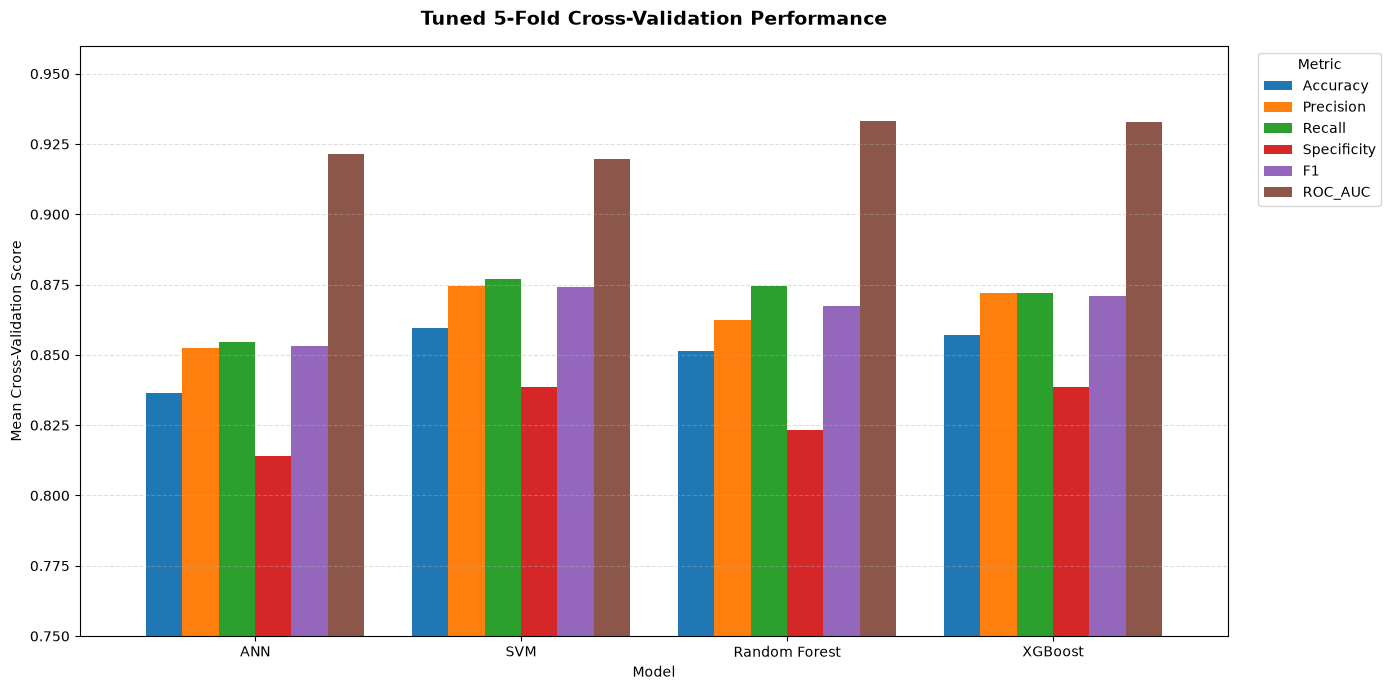

In [97]:
# ============================================================
# PHASE 16.4 — TUNED MODEL COMPARISON CHART
# ============================================================

tuned_metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC_AUC"
]

tuned_chart_data = tuned_cv_results[
    ["Model"] + tuned_metrics_to_plot
].copy()

tuned_chart_data = tuned_chart_data.set_index("Model")

ax = tuned_chart_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82
)

plt.title(
    "Tuned 5-Fold Cross-Validation Performance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Model")
plt.ylabel("Mean Cross-Validation Score")

plt.ylim(0.75, 0.96)
plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

save_chart(
    "tuned_cv_comparison.png",
    "model_performance"
)

plt.show()

In [98]:
# ============================================================
# PHASE 16.5 — TUNED GENERALISATION GAP
# ============================================================

tuned_generalisation_gap = tuned_cv_results[
    [
        "Model",
        "Train_ROC_AUC",
        "ROC_AUC"
    ]
].copy()

tuned_generalisation_gap["ROC_AUC_Gap"] = (
    tuned_generalisation_gap["Train_ROC_AUC"]
    - tuned_generalisation_gap["ROC_AUC"]
)

tuned_generalisation_gap = tuned_generalisation_gap.rename(
    columns={
        "ROC_AUC": "CV_ROC_AUC"
    }
)

display(
    tuned_generalisation_gap.round(4)
)

save_table(
    tuned_generalisation_gap,
    "tuned_generalisation_gap.csv",
    index=False
)

,Model,Train_ROC_AUC,CV_ROC_AUC,ROC_AUC_Gap
0,ANN,0.9280,0.9214,0.0065
1,SVM,0.9615,0.9197,0.0418
2,Random Forest,0.9759,0.9333,0.0426
3,XGBoost,0.9712,0.9329,0.0382


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/tuned_generalisation_gap.csv


PosixPath('/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/tuned_generalisation_gap.csv')

In [99]:
# ============================================================
# PHASE 16.6 — FEATURE SELECTION K SUMMARY
# ============================================================

selected_k_summary = pd.DataFrame({
    "Model": [
        "ANN",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "Selected_k": [
        ann_random_search.best_params_["feature_selection__k"],
        svm_random_search.best_params_["feature_selection__k"],
        random_forest_random_search.best_params_["feature_selection__k"],
        xgboost_random_search.best_params_["feature_selection__k"]
    ],

    "Best_CV_ROC_AUC": [
        ann_random_search.best_score_,
        svm_random_search.best_score_,
        random_forest_random_search.best_score_,
        xgboost_random_search.best_score_
    ]
})

display(selected_k_summary)

save_table(
    selected_k_summary,
    "feature_selection_k_summary.csv",
    index=False
)

,Model,Selected_k,Best_CV_ROC_AUC
0,ANN,15,0.921444
1,SVM,all,0.919704
2,Random Forest,15,0.933267
3,XGBoost,15,0.932922


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/feature_selection_k_summary.csv


PosixPath('/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/feature_selection_k_summary.csv')

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/feature_selection/feature_selection_k_comparison.png


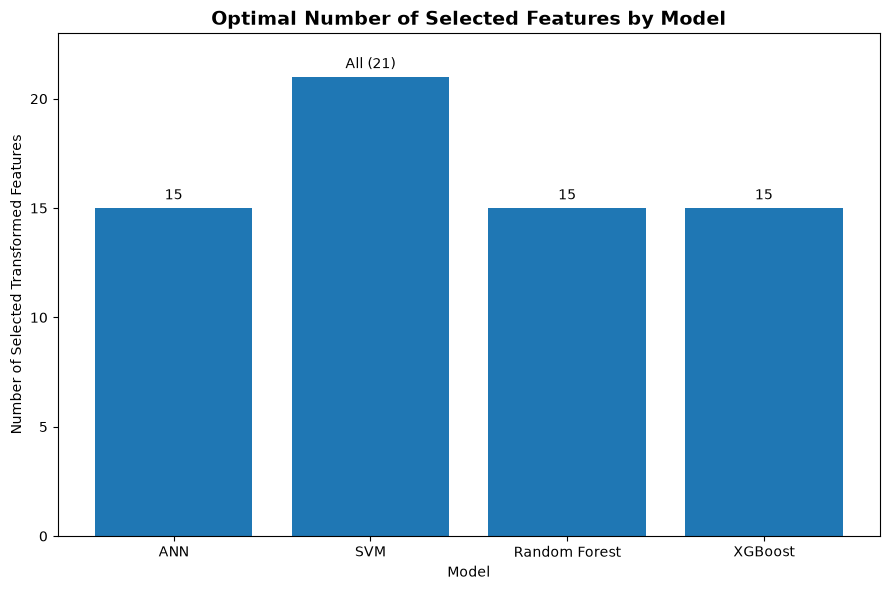

In [100]:
# ============================================================
# PHASE 16.7 — FEATURE SELECTION K COMPARISON CHART
# ============================================================

k_chart_data = selected_k_summary.copy()

# If a model selected "all", represent it as all 21 transformed features
k_chart_data["Selected_k_for_plot"] = (
    k_chart_data["Selected_k"]
    .apply(
        lambda value: 21 if value == "all" else int(value)
    )
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    k_chart_data["Model"],
    k_chart_data["Selected_k_for_plot"]
)

ax.set_title(
    "Optimal Number of Selected Features by Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Number of Selected Transformed Features")

ax.set_ylim(
    0,
    23
)

for bar, original_k in zip(
    bars,
    k_chart_data["Selected_k"]
):
    label = "All (21)" if original_k == "all" else str(original_k)

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        label,
        ha="center"
    )

plt.tight_layout()

save_chart(
    "feature_selection_k_comparison.png",
    "feature_selection",
    fig
)

plt.show()

In [101]:
# ============================================================
# PHASE 16.8 — IDENTIFY CV-SELECTED MODEL
# ============================================================

cv_selected_model_name = (
    tuned_cv_results
    .sort_values(
        by="ROC_AUC",
        ascending=False
    )
    .iloc[0]["Model"]
)

cv_selected_model = tuned_model_pipelines[
    cv_selected_model_name
]

print("Primary model-selection metric: ROC-AUC")
print("CV-selected model:", cv_selected_model_name)

print(
    "CV ROC-AUC:",
    round(
        tuned_cv_results
        .set_index("Model")
        .loc[cv_selected_model_name, "ROC_AUC"],
        4
    )
)

Primary model-selection metric: ROC-AUC
CV-selected model: Random Forest
CV ROC-AUC: 0.9333


# PHASE 17 — FINAL MODEL TRAINING AND UNTOUCHED TEST EVALUATION

In [102]:
# ============================================================
# PHASE 17.1 — FIT FINAL TUNED MODELS
# TRAINING DATA ONLY
# ============================================================

final_models = {}

for model_name, tuned_pipeline in tuned_model_pipelines.items():

    print(f"Fitting final {model_name}...")

    final_model = clone(tuned_pipeline)

    final_model.fit(
        X_train,
        y_train
    )

    final_models[model_name] = final_model

    print(f"Final {model_name} fitted successfully.\n")

print("All final tuned models fitted successfully.")

Fitting final ANN...
Final ANN fitted successfully.

Fitting final SVM...
Final SVM fitted successfully.

Fitting final Random Forest...
Final Random Forest fitted successfully.

Fitting final XGBoost...
Final XGBoost fitted successfully.

All final tuned models fitted successfully.


In [103]:
# ============================================================
# PHASE 17.2 — IMPORT FINAL EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Final evaluation metrics imported successfully.")

Final evaluation metrics imported successfully.


In [104]:
# ============================================================
# PHASE 17.3 — FINAL UNTOUCHED TEST EVALUATION
# ============================================================

final_test_records = []

final_predictions = {}
final_probabilities = {}

for model_name, model in final_models.items():

    print(f"Evaluating {model_name} on untouched test set...")

    # Class predictions
    y_pred = model.predict(X_test)

    # Probability of HeartDisease = 1
    y_prob = model.predict_proba(X_test)[:, 1]

    # Store for later ROC/PR/confusion matrix analysis
    final_predictions[model_name] = y_pred
    final_probabilities[model_name] = y_prob

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    final_test_records.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    print(f"{model_name} completed.\n")


final_test_results = pd.DataFrame(
    final_test_records
)

display(
    final_test_results.round(4)
)

Evaluating ANN on untouched test set...
ANN completed.

Evaluating SVM on untouched test set...
SVM completed.

Evaluating Random Forest on untouched test set...
Random Forest completed.

Evaluating XGBoost on untouched test set...
XGBoost completed.



,Model,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,TN,FP,FN,TP
0,ANN,0.8261,0.8889,0.7843,0.8780,0.8333,0.9223,72,10,22,80
1,SVM,0.8696,0.8750,0.8922,0.8415,0.8835,0.9274,69,13,11,91
2,Random Forest,0.8804,0.8774,0.9118,0.8415,0.8942,0.9278,69,13,9,93
3,XGBoost,0.8750,0.8835,0.8922,0.8537,0.8878,0.9250,70,12,11,91


In [105]:
# ============================================================
# PHASE 17.4 — SAVE FINAL TEST RESULTS
# ============================================================

save_table(
    final_test_results,
    "final_test_performance.csv",
    index=False
)

print("Final untouched test results saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/final_test_performance.csv
Final untouched test results saved successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_performance/final_test_performance_comparison.png


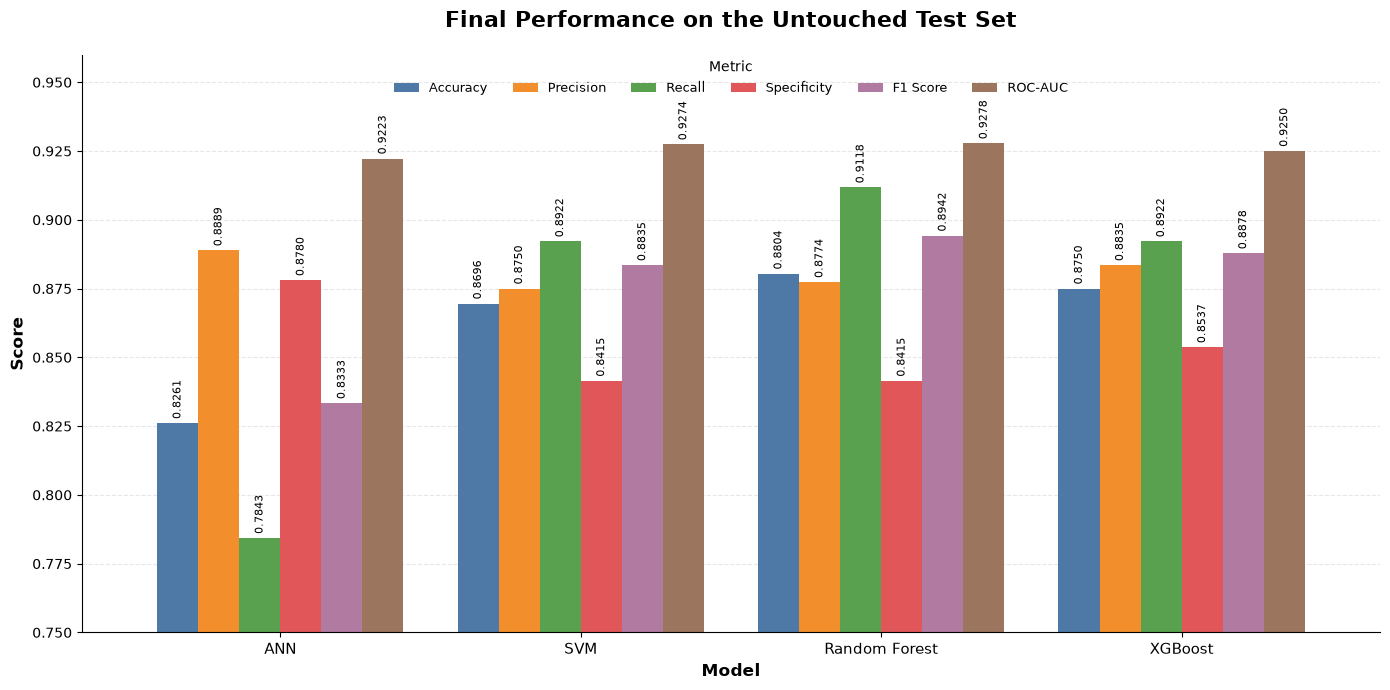

In [182]:
# ============================================================
# PHASE 17.5 — FINAL TEST PERFORMANCE COMPARISON CHART
# IMPROVED STYLE WITH VALUE LABELS
# ============================================================

import matplotlib.pyplot as plt

# Metrics from the new final notebook
final_metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC_AUC"
]

# Prepare chart data
final_chart_data = final_test_results[
    ["Model"] + final_metrics_to_plot
].copy()

final_chart_data = final_chart_data.set_index("Model")

# Professional muted colours
metric_colors = [
    "#4E79A7",   # Accuracy
    "#F28E2B",   # Precision
    "#59A14F",   # Recall
    "#E15759",   # Specificity
    "#B07AA1",   # F1
    "#9C755F"    # ROC-AUC
]

# Create grouped bar chart
ax = final_chart_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82,
    color=metric_colors
)

# Title
plt.title(
    "Final Performance on the Untouched Test Set",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Axis labels
plt.xlabel(
    "Model",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Score",
    fontsize=12,
    fontweight="bold"
)

# Y-axis range
plt.ylim(
    0.75,
    0.96
)

plt.xticks(
    rotation=0,
    fontsize=11
)

plt.yticks(
    fontsize=10
)

# ------------------------------------------------------------
# ADD VALUE LABEL ABOVE EACH BAR
# ------------------------------------------------------------

for container in ax.containers:

    labels = [
        f"{bar.get_height():.4f}"
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8,
        rotation=90
    )

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

ax.set_axisbelow(True)

# Cleaner legend names
legend_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1 Score",
    "ROC-AUC"
]

ax.legend(
    legend_labels,
    title="Metric",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=6,
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save over the existing chart
save_chart(
    "final_test_performance_comparison.png",
    "model_performance"
)

plt.show()

In [107]:
# ============================================================
# PHASE 17.6 — FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

final_ranked_results = (
    final_test_results
    .sort_values(
        by="ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    final_ranked_results.round(4)
)

print("CV-selected model:", cv_selected_model_name)

print(
    "Best final test model by ROC-AUC:",
    final_ranked_results.iloc[0]["Model"]
)

print(
    "Best final test model by Accuracy:",
    final_test_results
    .sort_values("Accuracy", ascending=False)
    .iloc[0]["Model"]
)

print(
    "Best final test model by Recall:",
    final_test_results
    .sort_values("Recall", ascending=False)
    .iloc[0]["Model"]
)

print(
    "Best final test model by F1:",
    final_test_results
    .sort_values("F1", ascending=False)
    .iloc[0]["Model"]
)

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,TN,FP,FN,TP
0,Random Forest,0.8804,0.8774,0.9118,0.8415,0.8942,0.9278,69,13,9,93
1,SVM,0.8696,0.8750,0.8922,0.8415,0.8835,0.9274,69,13,11,91
2,XGBoost,0.8750,0.8835,0.8922,0.8537,0.8878,0.9250,70,12,11,91
3,ANN,0.8261,0.8889,0.7843,0.8780,0.8333,0.9223,72,10,22,80


CV-selected model: Random Forest
Best final test model by ROC-AUC: Random Forest
Best final test model by Accuracy: Random Forest
Best final test model by Recall: Random Forest
Best final test model by F1: Random Forest


# PHASE 18 — CONFUSION MATRIX ANALYSIS

In [108]:
# ============================================================
# PHASE 18.1 — IMPORT CONFUSION MATRIX DISPLAY
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

print("Confusion matrix display imported successfully.")

Confusion matrix display imported successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/confusion_matrix_ann.png


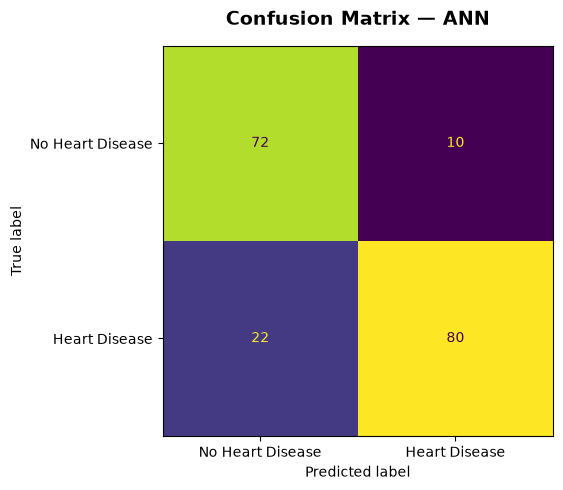

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/confusion_matrix_svm.png


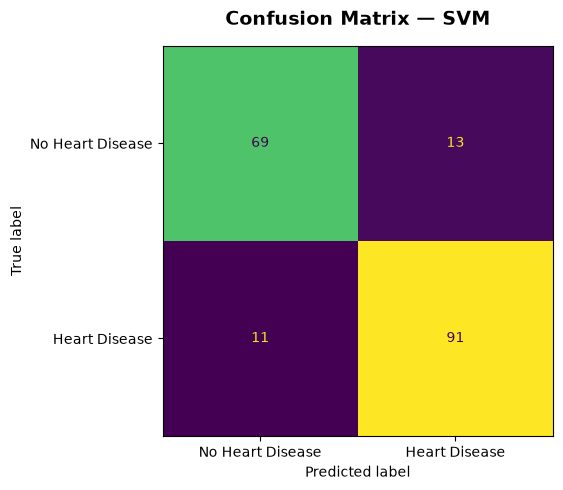

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/confusion_matrix_random_forest.png


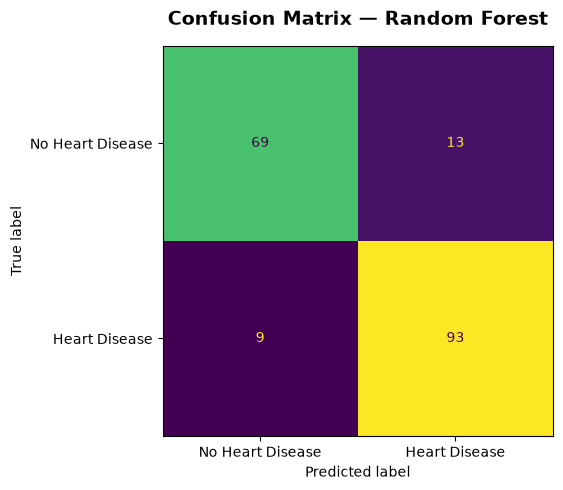

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/confusion_matrix_xgboost.png


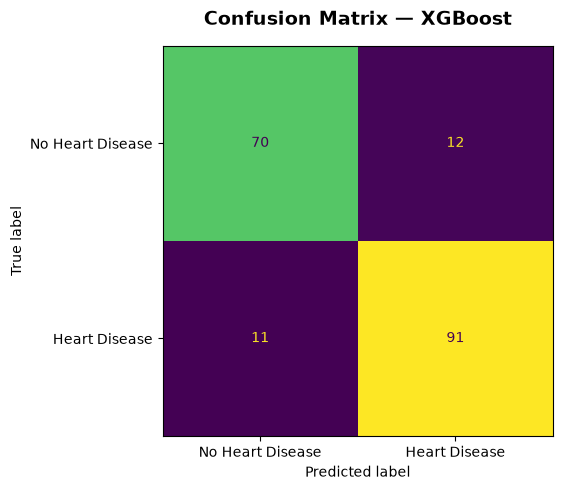

In [109]:
# ============================================================
# PHASE 18.2 — CONFUSION MATRICES FOR ALL FINAL MODELS
# ============================================================

for model_name in final_models.keys():

    y_pred = final_predictions[model_name]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )

    display_cm.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(
        f"Confusion Matrix — {model_name}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()

    filename = (
        f"confusion_matrix_"
        f"{model_name.lower().replace(' ', '_')}.png"
    )

    save_chart(
        filename,
        "model_evaluation",
        fig
    )

    plt.show()

In [110]:
# ============================================================
# PHASE 18.3 — CONFUSION MATRIX SUMMARY
# ============================================================

confusion_summary = final_test_results[
    [
        "Model",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
].copy()

confusion_summary = confusion_summary.rename(
    columns={
        "TN": "True_Negatives",
        "FP": "False_Positives",
        "FN": "False_Negatives",
        "TP": "True_Positives"
    }
)

display(confusion_summary)

save_table(
    confusion_summary,
    "confusion_matrix_summary.csv",
    index=False
)

print("Confusion matrix summary saved successfully.")

,Model,True_Negatives,False_Positives,False_Negatives,True_Positives
0,ANN,72,10,22,80
1,SVM,69,13,11,91
2,Random Forest,69,13,9,93
3,XGBoost,70,12,11,91


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/confusion_matrix_summary.csv
Confusion matrix summary saved successfully.


# PHASE 19 — ROC CURVE ANALYSIS

In [111]:
# ============================================================
# PHASE 19.1 — IMPORT ROC CURVE TOOLS
# ============================================================

from sklearn.metrics import roc_curve, auc

print("ROC curve tools imported successfully.")

ROC curve tools imported successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/confusion_matrix_ann.png


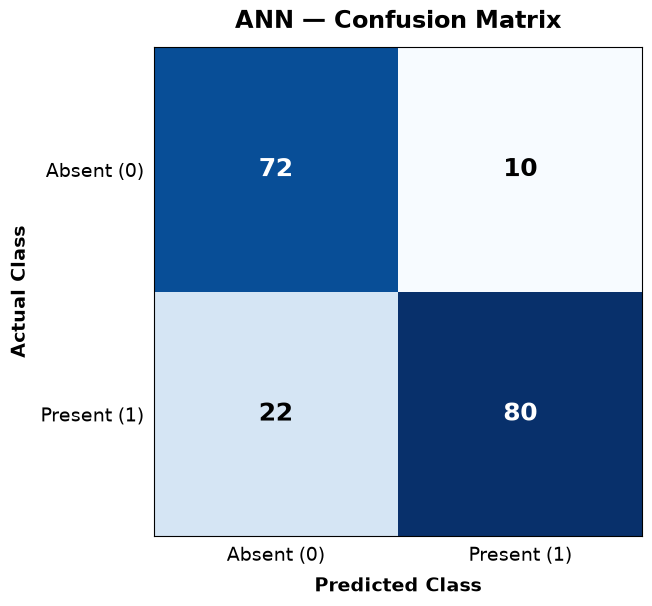

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/confusion_matrix_svm.png


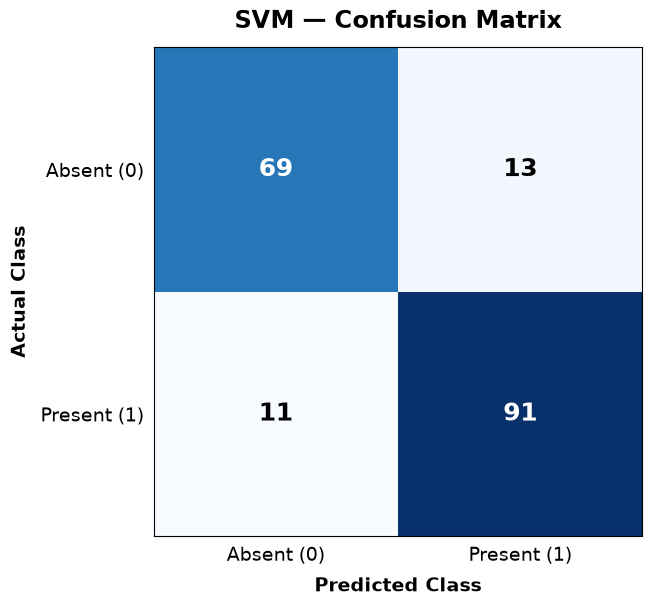

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/confusion_matrix_random_forest.png


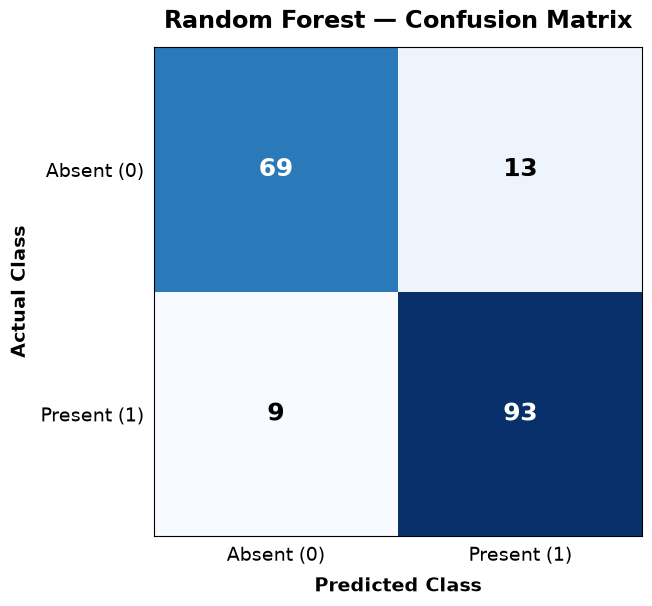

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/confusion_matrix_xgboost.png


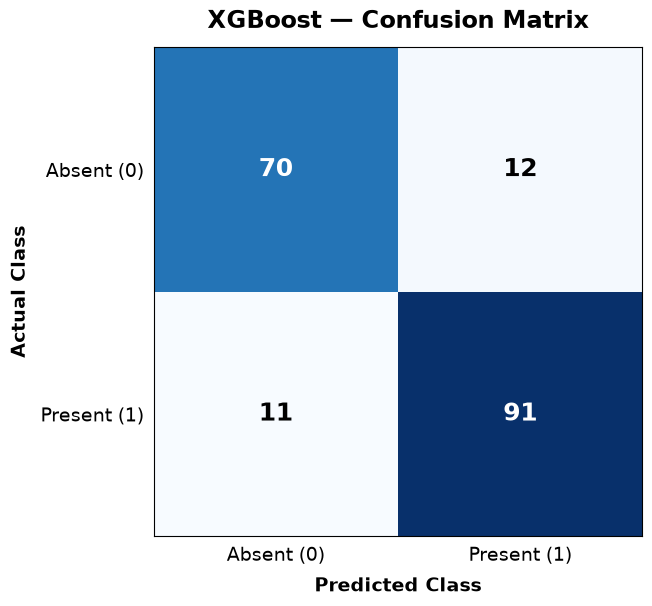

Documentation-quality confusion matrices created successfully.


In [180]:
# ============================================================
# PHASE 19.1A — INDIVIDUAL CONFUSION MATRICES
# COMPACT DOCUMENTATION STYLE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix

cm_file_names = {
    "ANN": "confusion_matrix_ann.png",
    "SVM": "confusion_matrix_svm.png",
    "Random Forest": "confusion_matrix_random_forest.png",
    "XGBoost": "confusion_matrix_xgboost.png"
}

# Shorter labels = much clearer when inserted into Word/Google Docs
class_labels = [
    "Absent (0)",
    "Present (1)"
]

for model_name in final_models.keys():

    y_pred = final_predictions[model_name]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    # Large source image, but compact proportions
    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    # Draw confusion matrix
    image = ax.imshow(
        cm,
        cmap="Blues",
        interpolation="nearest"
    )

    # IMPORTANT:
    # No colour bar because it wastes space in the report table

    # Tick positions
    ax.set_xticks(
        np.arange(len(class_labels))
    )

    ax.set_yticks(
        np.arange(len(class_labels))
    )

    # Tick labels
    ax.set_xticklabels(
        class_labels,
        fontsize=14
    )

    ax.set_yticklabels(
        class_labels,
        fontsize=14
    )

    # Axis labels
    ax.set_xlabel(
        "Predicted Class",
        fontsize=14,
        fontweight="bold",
        labelpad=8
    )

    ax.set_ylabel(
        "Actual Class",
        fontsize=14,
        fontweight="bold",
        labelpad=8
    )

    # Title
    ax.set_title(
        f"{model_name} — Confusion Matrix",
        fontsize=17,
        fontweight="bold",
        pad=14
    )

    # Add values inside matrix cells
    threshold = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=18,
                fontweight="bold",
                color="white" if cm[i, j] > threshold else "black"
            )

    # Keep the actual matrix perfectly square
    ax.set_box_aspect(1)

    # Remove tick marks
    ax.tick_params(
        axis="both",
        length=0,
        pad=7
    )

    # Reduce unnecessary whitespace
    plt.tight_layout(
        pad=0.5
    )

    # Save high-resolution version
    folder = CHARTS_DIR / "model_evaluation"
    folder.mkdir(parents=True, exist_ok=True)

    filepath = folder / cm_file_names[model_name]

    fig.savefig(
        filepath,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05
    )

    print(f"Saved chart: {filepath}")

    plt.show()

print("Documentation-quality confusion matrices created successfully.")

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/roc_curves_all_models.png


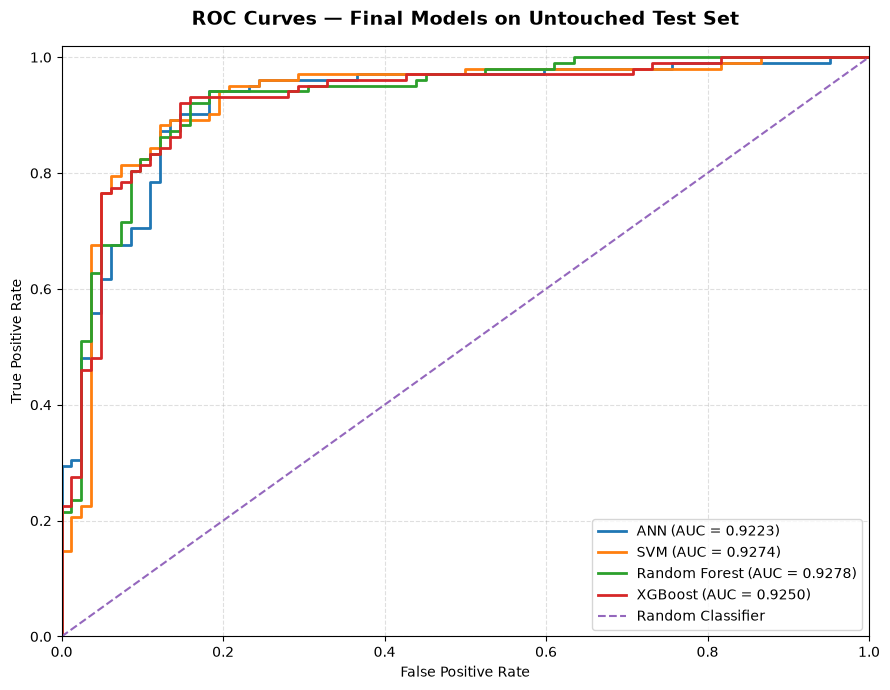

In [112]:
# ============================================================
# PHASE 19.2 — COMBINED ROC CURVE FOR ALL FINAL MODELS
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

for model_name in final_models.keys():

    y_prob = final_probabilities[model_name]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc_value:.4f})"
    )

# Random classifier reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

ax.set_title(
    "ROC Curves — Final Models on Untouched Test Set",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

ax.grid(
    linestyle="--",
    alpha=0.4
)

ax.legend(
    loc="lower right"
)

plt.tight_layout()

save_chart(
    "roc_curves_all_models.png",
    "model_evaluation",
    fig
)

plt.show()

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/roc_curve_ann.png


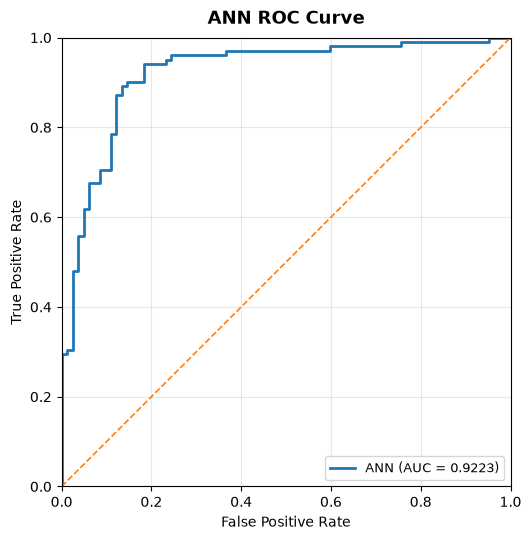

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/roc_curve_svm.png


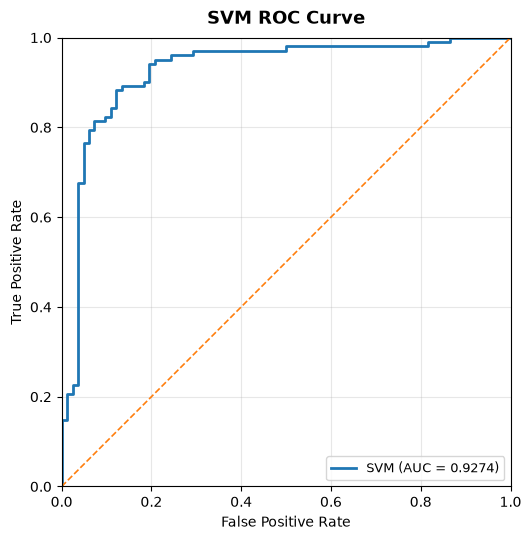

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/roc_curve_random_forest.png


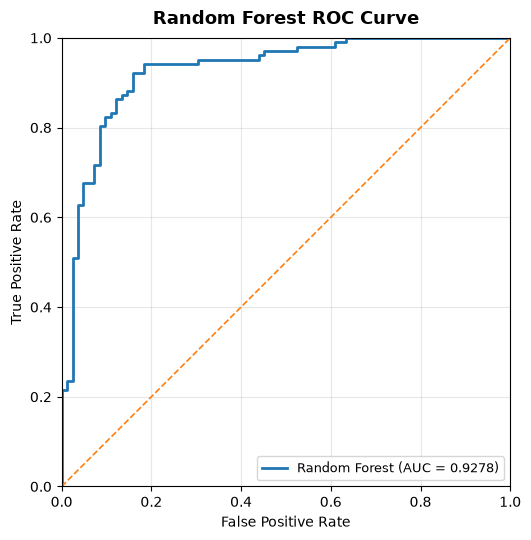

Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/roc_curve_xgboost.png


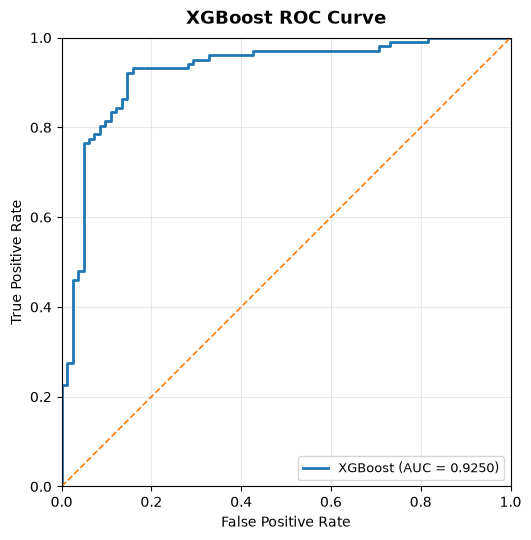

Individual ROC curves created successfully.


In [175]:
# ============================================================
# PHASE 19.3 — INDIVIDUAL ROC CURVES FOR FINAL MODELS
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

roc_file_names = {
    "ANN": "roc_curve_ann.png",
    "SVM": "roc_curve_svm.png",
    "Random Forest": "roc_curve_random_forest.png",
    "XGBoost": "roc_curve_xgboost.png"
}

for model_name in final_models.keys():

    y_prob = final_probabilities[model_name]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calculate ROC-AUC
    roc_auc_value = auc(fpr, tpr)

    # Create figure with a similar proportion to the old documentation
    fig, ax = plt.subplots(
        figsize=(6, 5.5)
    )

    # ROC curve
    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc_value:.4f})"
    )

    # Random classifier reference line
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.2
    )

    # Title
    ax.set_title(
        f"{model_name} ROC Curve",
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    # Axis labels
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    # Axis limits
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # IMPORTANT:
    # Makes the actual graph area square like your old documentation
    ax.set_box_aspect(1)

    # Grid
    ax.grid(
        linestyle="-",
        alpha=0.3
    )

    # Legend
    ax.legend(
        loc="lower right",
        fontsize=9
    )

    plt.tight_layout()

    # Save image
    save_chart(
        roc_file_names[model_name],
        "model_evaluation",
        fig
    )

    plt.show()

print("Individual ROC curves created successfully.")

In [113]:
# ============================================================
# PHASE 19.3 — SAVE ROC-AUC SUMMARY
# ============================================================

roc_auc_summary = final_test_results[
    [
        "Model",
        "ROC_AUC"
    ]
].copy()

roc_auc_summary = (
    roc_auc_summary
    .sort_values(
        by="ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(roc_auc_summary.round(4))

save_table(
    roc_auc_summary,
    "roc_auc_summary.csv",
    index=False
)

print("ROC-AUC summary saved successfully.")

,Model,ROC_AUC
0,Random Forest,0.9278
1,SVM,0.9274
2,XGBoost,0.9250
3,ANN,0.9223


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/roc_auc_summary.csv
ROC-AUC summary saved successfully.


# PHASE 20 — PRECISION–RECALL CURVE ANALYSIS

In [114]:
# ============================================================
# PHASE 20.1 — IMPORT PRECISION-RECALL TOOLS
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

print("Precision-Recall tools imported successfully.")

Precision-Recall tools imported successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/model_evaluation/precision_recall_curves_all_models.png


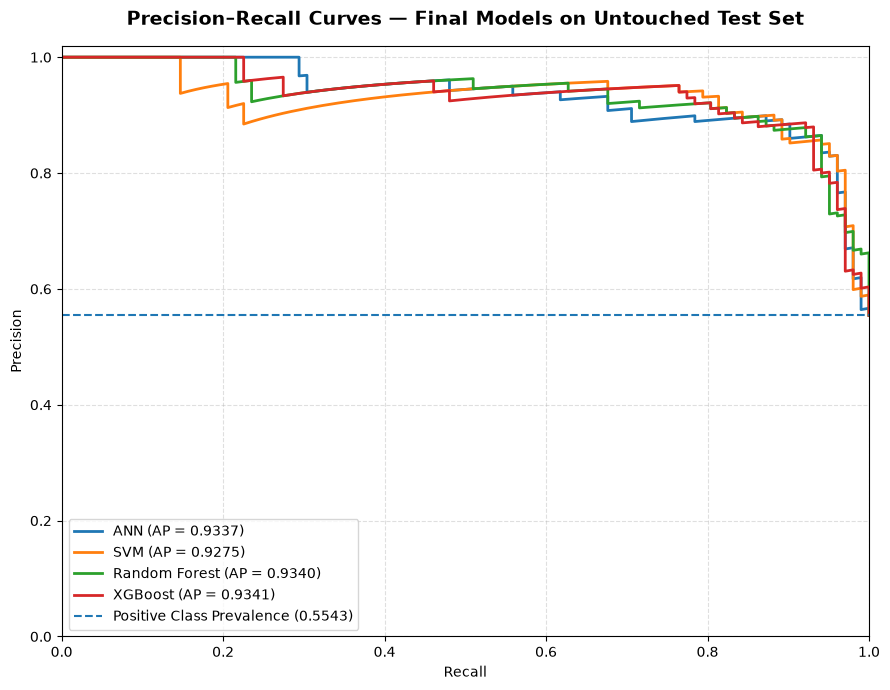

In [115]:
# ============================================================
# PHASE 20.2 — COMBINED PRECISION-RECALL CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

for model_name in final_models.keys():

    y_prob = final_probabilities[model_name]

    precision_curve, recall_curve, thresholds = (
        precision_recall_curve(
            y_test,
            y_prob
        )
    )

    average_precision = average_precision_score(
        y_test,
        y_prob
    )

    ax.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AP = {average_precision:.4f})"
        )
    )

# Positive-class prevalence reference line
positive_prevalence = y_test.mean()

ax.axhline(
    y=positive_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Positive Class Prevalence "
        f"({positive_prevalence:.4f})"
    )
)

ax.set_title(
    "Precision–Recall Curves — Final Models on Untouched Test Set",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

ax.grid(
    linestyle="--",
    alpha=0.4
)

ax.legend(
    loc="lower left"
)

plt.tight_layout()

save_chart(
    "precision_recall_curves_all_models.png",
    "model_evaluation",
    fig
)

plt.show()

# PHASE 21 — SELECTED FEATURE ANALYSIS

In [116]:
# ============================================================
# PHASE 21.1 — EXTRACT SELECTED FEATURES FOR ALL MODELS
# ============================================================

selected_feature_records = []

for model_name, model in final_models.items():

    # Get fitted preprocessor and selector
    fitted_preprocessor = model.named_steps["preprocessor"]
    fitted_selector = model.named_steps["feature_selection"]

    # Get transformed feature names
    feature_names = fitted_preprocessor.get_feature_names_out()

    # Clean prefixes for readability
    clean_names = [
        name.replace("num__", "").replace("cat__", "")
        for name in feature_names
    ]

    # Get selected feature mask
    selected_mask = fitted_selector.get_support()

    selected_features = [
        feature
        for feature, selected in zip(
            clean_names,
            selected_mask
        )
        if selected
    ]

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Number of selected features:", len(selected_features))
    print(selected_features)

    for feature in selected_features:
        selected_feature_records.append({
            "Model": model_name,
            "Selected_Feature": feature
        })

selected_features_summary = pd.DataFrame(
    selected_feature_records
)


ANN
---
Number of selected features: 15
['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'FastingBS_0', 'FastingBS_1', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

SVM
---
Number of selected features: 21
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'FastingBS_0', 'FastingBS_1', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

Random Forest
-------------
Number of selected features: 15
['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'FastingBS_0', 'FastingBS_1', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

XGBoost
-------
Number of selected features: 15
['RestingBP'

In [117]:
# ============================================================
# PHASE 21.2 — SAVE SELECTED FEATURES FOR EACH MODEL
# ============================================================

for model_name in final_models.keys():

    model_features = (
        selected_features_summary[
            selected_features_summary["Model"] == model_name
        ]
        .reset_index(drop=True)
    )

    filename = (
        f"selected_features_"
        f"{model_name.lower().replace(' ', '_')}.csv"
    )

    save_table(
        model_features,
        filename,
        index=False
    )

print("Selected feature tables saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/selected_features_ann.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/selected_features_svm.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/selected_features_random_forest.csv
Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/selected_features_xgboost.csv
Selected feature tables saved successfully.


In [118]:
# ============================================================
# PHASE 21.3 — FEATURE SELECTION SUMMARY
# ============================================================

feature_selection_summary = (
    selected_features_summary
    .groupby("Model")
    .size()
    .reset_index(name="Number_of_Selected_Features")
)

feature_selection_summary["Total_Transformed_Features"] = 21

feature_selection_summary["Features_Removed"] = (
    feature_selection_summary["Total_Transformed_Features"]
    - feature_selection_summary["Number_of_Selected_Features"]
)

display(feature_selection_summary)

save_table(
    feature_selection_summary,
    "selected_feature_count_summary.csv",
    index=False
)

print("Feature-selection summary saved successfully.")

,Model,Number_of_Selected_Features,Total_Transformed_Features,Features_Removed
0,ANN,15,21,6
1,Random Forest,15,21,6
2,SVM,21,21,0
3,XGBoost,15,21,6


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/selected_feature_count_summary.csv
Feature-selection summary saved successfully.


# PHASE 22 — FEATURE IMPORTANCE ANALYSIS

In [119]:
# ============================================================
# PHASE 22.1 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_model = final_models["Random Forest"]

rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_selector = rf_model.named_steps["feature_selection"]
rf_classifier = rf_model.named_steps["classifier"]

# Get transformed feature names
rf_feature_names = rf_preprocessor.get_feature_names_out()

rf_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in rf_feature_names
]

# Keep only selected features
rf_selected_names = np.array(
    rf_feature_names
)[rf_selector.get_support()]

# Get feature importance values
rf_importances = rf_classifier.feature_importances_

random_forest_importance = pd.DataFrame({
    "Feature": rf_selected_names,
    "Importance": rf_importances
})

random_forest_importance = (
    random_forest_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(random_forest_importance)

,Feature,Importance
0,ST_Slope_Up,0.207853
1,ST_Slope_Flat,0.148537
2,ChestPainType_ASY,0.107113
3,Oldpeak,0.087074
4,MaxHR,0.086531
5,ExerciseAngina_N,0.083303
6,ExerciseAngina_Y,0.066234
7,Cholesterol,0.046546
8,RestingBP,0.045250
9,Sex_F,0.025573


In [120]:
# ============================================================
# PHASE 22.2 — SAVE RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

save_table(
    random_forest_importance,
    "random_forest_feature_importance.csv",
    index=False
)

print("Random Forest feature importance saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/random_forest_feature_importance.csv
Random Forest feature importance saved successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/feature_importance/random_forest_feature_importance.png


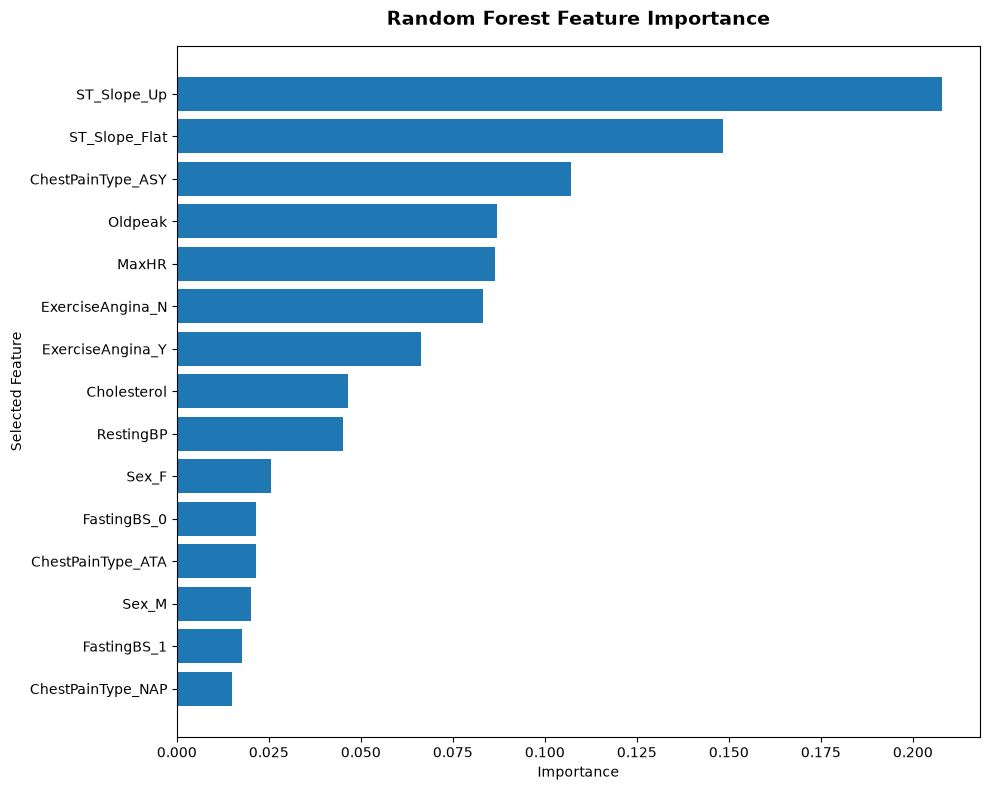

In [121]:
# ============================================================
# PHASE 22.3 — RANDOM FOREST FEATURE IMPORTANCE CHART
# ============================================================

rf_plot_data = random_forest_importance.sort_values(
    by="Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    rf_plot_data["Feature"],
    rf_plot_data["Importance"]
)

ax.set_title(
    "Random Forest Feature Importance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Importance")
ax.set_ylabel("Selected Feature")

plt.tight_layout()

save_chart(
    "random_forest_feature_importance.png",
    "feature_importance",
    fig
)

plt.show()

In [122]:
# ============================================================
# PHASE 22.4 — XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_model = final_models["XGBoost"]

xgb_preprocessor = xgb_model.named_steps["preprocessor"]
xgb_selector = xgb_model.named_steps["feature_selection"]
xgb_classifier = xgb_model.named_steps["classifier"]

# Get transformed feature names
xgb_feature_names = xgb_preprocessor.get_feature_names_out()

xgb_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in xgb_feature_names
]

# Keep only selected features
xgb_selected_names = np.array(
    xgb_feature_names
)[xgb_selector.get_support()]

# Get importance values
xgb_importances = xgb_classifier.feature_importances_

xgboost_importance = pd.DataFrame({
    "Feature": xgb_selected_names,
    "Importance": xgb_importances
})

xgboost_importance = (
    xgboost_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(xgboost_importance)

,Feature,Importance
0,ST_Slope_Up,0.406993
1,ChestPainType_ASY,0.076524
2,ExerciseAngina_N,0.062264
3,ST_Slope_Flat,0.061204
4,FastingBS_0,0.059433
5,FastingBS_1,0.058011
6,Sex_F,0.052210
7,ExerciseAngina_Y,0.043409
8,Sex_M,0.043378
9,Oldpeak,0.030933


In [123]:
# ============================================================
# PHASE 22.5 — SAVE XGBOOST FEATURE IMPORTANCE
# ============================================================

save_table(
    xgboost_importance,
    "xgboost_feature_importance.csv",
    index=False
)

print("XGBoost feature importance saved successfully.")

Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/xgboost_feature_importance.csv
XGBoost feature importance saved successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/feature_importance/xgboost_feature_importance.png


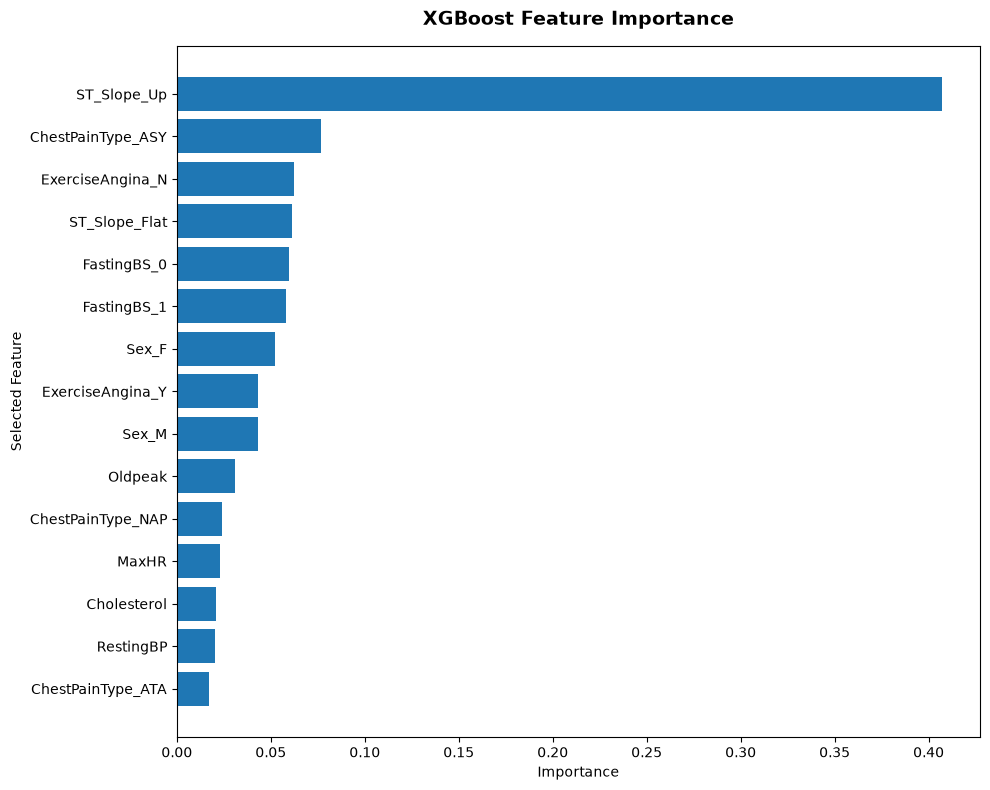

In [124]:
# ============================================================
# PHASE 22.6 — XGBOOST FEATURE IMPORTANCE CHART
# ============================================================

xgb_plot_data = xgboost_importance.sort_values(
    by="Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    xgb_plot_data["Feature"],
    xgb_plot_data["Importance"]
)

ax.set_title(
    "XGBoost Feature Importance",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Importance")
ax.set_ylabel("Selected Feature")

plt.tight_layout()

save_chart(
    "xgboost_feature_importance.png",
    "feature_importance",
    fig
)

plt.show()

# PHASE 23 — FINAL MODEL DIAGNOSTICS

In [125]:
# ============================================================
# PHASE 23.1 — IMPORT LEARNING CURVE TOOLS
# ============================================================

from sklearn.model_selection import learning_curve

print("Learning curve tools imported successfully.")

Learning curve tools imported successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/final_model/final_model_learning_curve.png


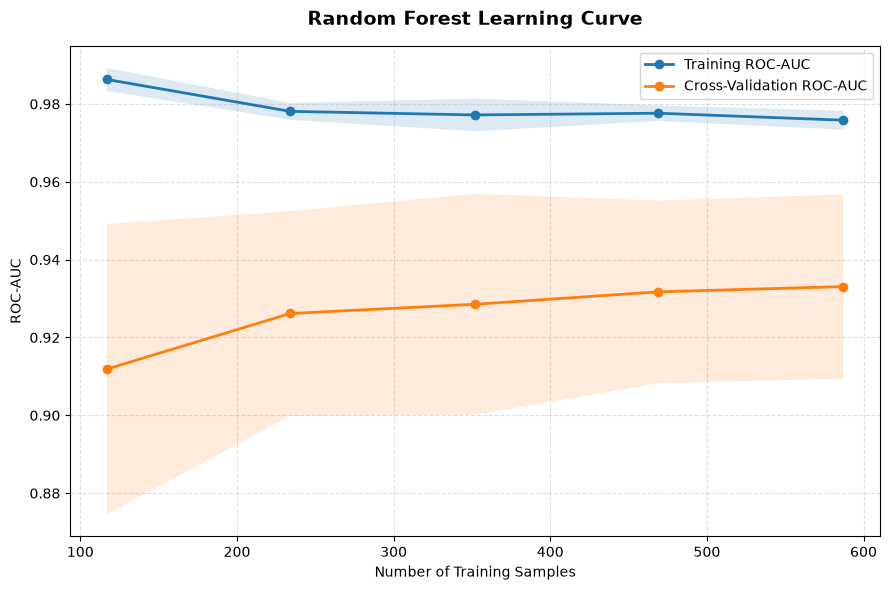

In [127]:
# ============================================================
# PHASE 23.2 — RANDOM FOREST LEARNING CURVE
# TRAINING DATA ONLY
# ============================================================

final_preferred_model = final_models["Random Forest"]

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=final_preferred_model,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    train_sizes,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training ROC-AUC"
)

ax.plot(
    train_sizes,
    validation_mean,
    marker="o",
    linewidth=2,
    label="Cross-Validation ROC-AUC"
)

ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

ax.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

ax.set_title(
    "Random Forest Learning Curve",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Training Samples")
ax.set_ylabel("ROC-AUC")

ax.grid(
    linestyle="--",
    alpha=0.4
)

ax.legend()

plt.tight_layout()

save_chart(
    "final_model_learning_curve.png",
    "final_model",
    fig
)

plt.show()

In [128]:
# ============================================================
# PHASE 23.3 — IMPORT CALIBRATION TOOLS
# ============================================================

from sklearn.calibration import calibration_curve

print("Calibration tools imported successfully.")

Calibration tools imported successfully.


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/final_model/final_model_calibration_curve.png


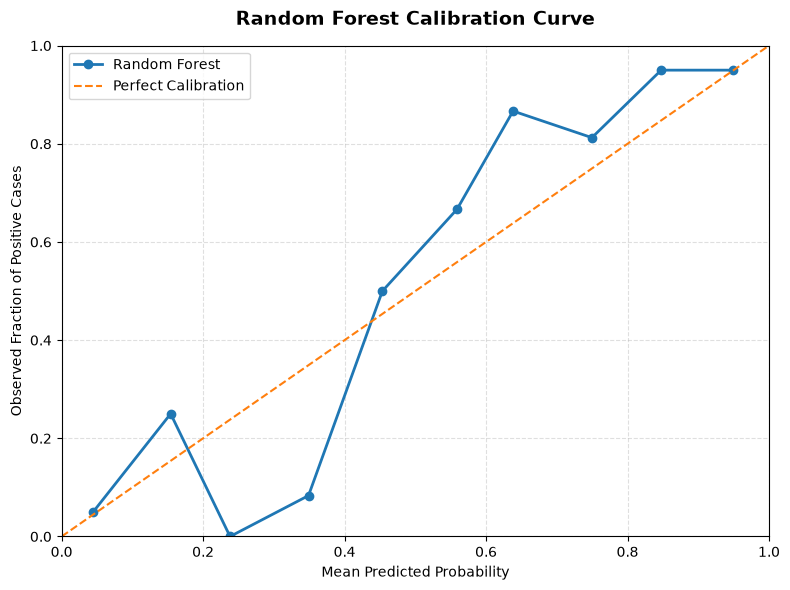

In [129]:
# ============================================================
# PHASE 23.4 — RANDOM FOREST CALIBRATION CURVE
# UNTOUCHED TEST SET USED FOR DIAGNOSTIC EVALUATION ONLY
# ============================================================

rf_test_probabilities = final_probabilities["Random Forest"]

fraction_of_positives, mean_predicted_probability = calibration_curve(
    y_test,
    rf_test_probabilities,
    n_bins=10,
    strategy="uniform"
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    mean_predicted_probability,
    fraction_of_positives,
    marker="o",
    linewidth=2,
    label="Random Forest"
)

# Perfect calibration reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect Calibration"
)

ax.set_title(
    "Random Forest Calibration Curve",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction of Positive Cases")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(
    linestyle="--",
    alpha=0.4
)

ax.legend()

plt.tight_layout()

save_chart(
    "final_model_calibration_curve.png",
    "final_model",
    fig
)

plt.show()

In [130]:
# ============================================================
# PHASE 23.5 — SAVE CALIBRATION RESULTS
# ============================================================

calibration_results = pd.DataFrame({
    "Mean_Predicted_Probability": mean_predicted_probability,
    "Observed_Fraction_Positive": fraction_of_positives
})

display(calibration_results.round(4))

save_table(
    calibration_results,
    "random_forest_calibration_results.csv",
    index=False
)

print("Calibration results saved successfully.")

,Mean_Predicted_Probability,Observed_Fraction_Positive
0,0.0446,0.0500
1,0.1542,0.2500
2,0.2381,0.0000
3,0.3490,0.0833
4,0.4535,0.5000
5,0.5590,0.6667
6,0.6382,0.8667
7,0.7496,0.8125
8,0.8476,0.9500
9,0.9494,0.9500


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/random_forest_calibration_results.csv
Calibration results saved successfully.


# PHASE 24 — SAVE FINAL MODEL PIPELINES

In [131]:
# ============================================================
# PHASE 24.1 — SAVE FINAL TRAINED PIPELINES
# ============================================================

model_filenames = {
    "ANN": "ann_pipeline.joblib",
    "SVM": "svm_pipeline.joblib",
    "Random Forest": "random_forest_pipeline.joblib",
    "XGBoost": "xgboost_pipeline.joblib"
}

for model_name, filename in model_filenames.items():

    filepath = MODELS_DIR / filename

    joblib.dump(
        final_models[model_name],
        filepath
    )

    print(f"Saved {model_name}: {filepath}")

print("\nAll final model pipelines saved successfully.")

Saved ANN: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/ann_pipeline.joblib
Saved SVM: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/svm_pipeline.joblib
Saved Random Forest: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/random_forest_pipeline.joblib
Saved XGBoost: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/xgboost_pipeline.joblib

All final model pipelines saved successfully.


In [132]:
# ============================================================
# PHASE 24.2 — DEFINE MODEL AND APPLICATION METADATA
# ============================================================

required_features = [
    "Age",
    "Sex",
    "ChestPainType",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "RestingECG",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope"
]

categorical_valid_values = {
    "Sex": sorted(df_clean["Sex"].dropna().unique().tolist()),
    "ChestPainType": sorted(
        df_clean["ChestPainType"].dropna().unique().tolist()
    ),
    "FastingBS": sorted(
        df_clean["FastingBS"].dropna().unique().tolist()
    ),
    "RestingECG": sorted(
        df_clean["RestingECG"].dropna().unique().tolist()
    ),
    "ExerciseAngina": sorted(
        df_clean["ExerciseAngina"].dropna().unique().tolist()
    ),
    "ST_Slope": sorted(
        df_clean["ST_Slope"].dropna().unique().tolist()
    )
}

class_labels = {
    0: "No Heart Disease",
    1: "Heart Disease"
}

print("Required features:")
print(required_features)

print("\nValid categorical values:")
for feature, values in categorical_valid_values.items():
    print(f"{feature}: {values}")

print("\nClass labels:")
print(class_labels)

Required features:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

Valid categorical values:
Sex: ['F', 'M']
ChestPainType: ['ASY', 'ATA', 'NAP', 'TA']
FastingBS: [0, 1]
RestingECG: ['LVH', 'Normal', 'ST']
ExerciseAngina: ['N', 'Y']
ST_Slope: ['Down', 'Flat', 'Up']

Class labels:
{0: 'No Heart Disease', 1: 'Heart Disease'}


In [133]:
# ============================================================
# PHASE 24.3 — DEFINE NUMERICAL VALIDATION RANGES
# ============================================================

validation_range_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

numerical_validation_ranges = {}

for feature in validation_range_features:

    valid_values = df_clean[feature].dropna()

    numerical_validation_ranges[feature] = {
        "min": float(valid_values.min()),
        "max": float(valid_values.max())
    }

print("Numerical validation ranges:")

for feature, ranges in numerical_validation_ranges.items():
    print(
        f"{feature}: "
        f"{ranges['min']} to {ranges['max']}"
    )

Numerical validation ranges:
Age: 28.0 to 77.0
RestingBP: 80.0 to 200.0
Cholesterol: 85.0 to 603.0
MaxHR: 60.0 to 202.0
Oldpeak: -2.6 to 6.2


In [183]:
# ============================================================
# PHASE 24.3.1 — PREPARE ROC AND SELECTED FEATURE DATA FOR UI
# ============================================================

from sklearn.metrics import roc_curve


# ------------------------------------------------------------
# SAVE ROC CURVE POINTS FOR EACH MODEL
# ------------------------------------------------------------

roc_curve_data = {}

for model_name in final_models.keys():

    y_probability = final_probabilities[
        model_name
    ]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    roc_curve_data[model_name] = {
        "fpr": fpr.tolist(),
        "tpr": tpr.tolist()
    }


# ------------------------------------------------------------
# SAVE SELECTED FEATURE NAMES FOR EACH MODEL
# ------------------------------------------------------------

selected_features_by_model = {}

for model_name in final_models.keys():

    model_features = (
        selected_features_summary[
            selected_features_summary["Model"]
            == model_name
        ]["Selected_Feature"]
        .tolist()
    )

    selected_features_by_model[
        model_name
    ] = model_features


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

for model_name in final_models.keys():

    print(f"\n{model_name}")
    print(
        "Selected features:",
        len(
            selected_features_by_model[
                model_name
            ]
        )
    )
    print(
        "ROC points:",
        len(
            roc_curve_data[
                model_name
            ]["fpr"]
        )
    )


ANN
Selected features: 15
ROC points: 38

SVM
Selected features: 21
ROC points: 40

Random Forest
Selected features: 15
ROC points: 42

XGBoost
Selected features: 15
ROC points: 44


In [184]:
# ============================================================
# PHASE 24.4 — CREATE COMPLETE MODEL BUNDLE
# ============================================================

model_bundle = {

    "models": final_models,

    "preferred_model_name": cv_selected_model_name,

    "required_features": required_features,

    "numerical_features": numerical_features,

    "categorical_features": categorical_features,

    "categorical_valid_values": categorical_valid_values,

    "numerical_validation_ranges": numerical_validation_ranges,

    "class_labels": class_labels,

    "target_name": "HeartDisease",

    "selected_feature_counts": {
        model_name: int(
            len(
                selected_features_summary[
                    selected_features_summary["Model"] == model_name
                ]
            )
        )
        for model_name in final_models
    },
    
    # Exact selected transformed feature names
    "selected_features": selected_features_by_model,
    
    # ROC curve coordinates from untouched test set
    "roc_curve_data": roc_curve_data,
    
    "final_test_results": final_test_results,
    
    "metadata": {
        "random_state": RANDOM_STATE,
        "training_records": len(X_train),
        "test_records": len(X_test),
        "total_original_predictors": 11,
        "total_transformed_features": 21
    }
}

MODEL_BUNDLE_PATH = (
    MODELS_DIR
    / "model_bundle.joblib"
)

joblib.dump(
    model_bundle,
    MODEL_BUNDLE_PATH
)

print("Model bundle saved successfully.")
print("Path:", MODEL_BUNDLE_PATH)

Model bundle saved successfully.
Path: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/model_bundle.joblib


In [135]:
# ============================================================
# PHASE 24.5 — VERIFY SAVED MODEL BUNDLE
# ============================================================

loaded_model_bundle = joblib.load(
    MODEL_BUNDLE_PATH
)

print("Model bundle loaded successfully.")

print(
    "Preferred model:",
    loaded_model_bundle["preferred_model_name"]
)

print(
    "Available models:",
    list(
        loaded_model_bundle["models"].keys()
    )
)

print(
    "Required input features:",
    len(
        loaded_model_bundle["required_features"]
    )
)

Model bundle loaded successfully.
Preferred model: Random Forest
Available models: ['ANN', 'SVM', 'Random Forest', 'XGBoost']
Required input features: 11


In [136]:
# ============================================================
# PHASE 24.6 — VERIFY RELOADED MODEL PREDICTION
# ============================================================

loaded_preferred_model = (
    loaded_model_bundle["models"][
        loaded_model_bundle["preferred_model_name"]
    ]
)

sample_patient = X_test.iloc[[0]].copy()

sample_prediction = loaded_preferred_model.predict(
    sample_patient
)[0]

sample_probability = loaded_preferred_model.predict_proba(
    sample_patient
)[0, 1]

print("Saved model prediction test successful.")

print(
    "Predicted class:",
    sample_prediction
)

print(
    "Predicted label:",
    class_labels[int(sample_prediction)]
)

print(
    "Heart disease probability:",
    round(
        sample_probability * 100,
        2
    ),
    "%"
)

Saved model prediction test successful.
Predicted class: 1
Predicted label: Heart Disease
Heart disease probability: 92.46 %


# PHASE 25 — INPUT VALIDATION AND SINGLE-PATIENT PREDICTION

In [141]:
# ============================================================
# PHASE 25.1 — DEFINE PATIENT INPUT VALIDATION FUNCTION
# ============================================================

def validate_patient_input(patient_data):
    """
    Validate one or more patient records before prediction.

    Returns
    -------
    cleaned_data : pandas.DataFrame
        Validated and cleaned input data.

    errors : list
        List of validation error messages.
    """

    errors = []

    # --------------------------------------------------------
    # 1. Ensure input is a DataFrame
    # --------------------------------------------------------
    if not isinstance(patient_data, pd.DataFrame):
        errors.append(
            "Input must be provided as a pandas DataFrame."
        )
        return None, errors

    if patient_data.empty:
        errors.append(
            "The input contains no patient records."
        )
        return None, errors

    cleaned_data = patient_data.copy()

    # --------------------------------------------------------
    # 2. Check required columns
    # --------------------------------------------------------
    missing_columns = [
        column
        for column in required_features
        if column not in cleaned_data.columns
    ]

    if missing_columns:
        errors.append(
            "Missing required column(s): "
            + ", ".join(missing_columns)
        )
        return None, errors

    # --------------------------------------------------------
    # 3. Check unexpected columns
    # --------------------------------------------------------
    unexpected_columns = [
        column
        for column in cleaned_data.columns
        if column not in required_features
    ]

    if unexpected_columns:
        errors.append(
            "Unexpected column(s): "
            + ", ".join(unexpected_columns)
        )
        return None, errors

    # Keep columns in expected order
    cleaned_data = cleaned_data[
        required_features
    ].copy()

    # --------------------------------------------------------
    # 4. Convert numerical fields to numeric
    # --------------------------------------------------------
    numeric_input_features = [
        "Age",
        "RestingBP",
        "Cholesterol",
        "MaxHR",
        "Oldpeak"
    ]

    for feature in numeric_input_features:

        original_values = cleaned_data[
            feature
        ].copy()

        cleaned_data[feature] = pd.to_numeric(
            cleaned_data[feature],
            errors="coerce"
        )

        invalid_numeric = (
            original_values.notna()
            &
            cleaned_data[feature].isna()
        )

        if invalid_numeric.any():
            errors.append(
                f"{feature} contains a non-numeric value."
            )

    # --------------------------------------------------------
    # 5. Validate FastingBS
    # --------------------------------------------------------
    original_fastingbs = cleaned_data[
        "FastingBS"
    ].copy()

    cleaned_data["FastingBS"] = pd.to_numeric(
        cleaned_data["FastingBS"],
        errors="coerce"
    )

    invalid_fasting_numeric = (
        original_fastingbs.notna()
        &
        cleaned_data["FastingBS"].isna()
    )

    if invalid_fasting_numeric.any():
        errors.append(
            "FastingBS must contain a valid numeric value."
        )

    elif not cleaned_data[
        "FastingBS"
    ].isin([0, 1]).all():
        errors.append(
            "FastingBS must be either 0 or 1."
        )

    # --------------------------------------------------------
    # 6. Validate categorical values
    # --------------------------------------------------------
    category_features_to_validate = [
        "Sex",
        "ChestPainType",
        "RestingECG",
        "ExerciseAngina",
        "ST_Slope"
    ]

    for feature in category_features_to_validate:

        valid_values = (
            categorical_valid_values[feature]
        )

        invalid_values = (
            ~cleaned_data[feature].isin(
                valid_values
            )
        )

        if invalid_values.any():

            detected_values = (
                cleaned_data.loc[
                    invalid_values,
                    feature
                ]
                .astype(str)
                .unique()
                .tolist()
            )

            errors.append(
                f"{feature} contains unsupported value(s): "
                + ", ".join(detected_values)
                + ". Valid values are: "
                + ", ".join(
                    map(str, valid_values)
                )
            )

    # --------------------------------------------------------
    # 7. Handle clinically invalid zero values
    # --------------------------------------------------------
    cleaned_data.loc[
        cleaned_data["RestingBP"] == 0,
        "RestingBP"
    ] = np.nan

    cleaned_data.loc[
        cleaned_data["Cholesterol"] == 0,
        "Cholesterol"
    ] = np.nan

    # --------------------------------------------------------
    # 8. Check numerical ranges
    # --------------------------------------------------------
    for feature, limits in (
        numerical_validation_ranges.items()
    ):

        non_missing_values = (
            cleaned_data[feature]
            .dropna()
        )

        below_minimum = (
            non_missing_values
            < limits["min"]
        ).any()

        above_maximum = (
            non_missing_values
            > limits["max"]
        ).any()

        if below_minimum or above_maximum:
            errors.append(
                f"{feature} must be between "
                f"{limits['min']} and "
                f"{limits['max']} based on "
                "the training dataset range."
            )

    # --------------------------------------------------------
    # 9. Age must be a whole number
    # --------------------------------------------------------
    age_values = (
        cleaned_data["Age"]
        .dropna()
    )

    if not age_values.apply(
        lambda value: float(value).is_integer()
    ).all():
        errors.append(
            "Age must be entered as a whole number."
        )

    # --------------------------------------------------------
    # 10. Return validation result
    # --------------------------------------------------------
    if errors:
        return None, errors

    cleaned_data["Age"] = (
        cleaned_data["Age"]
        .astype(int)
    )

    cleaned_data["FastingBS"] = (
        cleaned_data["FastingBS"]
        .astype(int)
    )

    return cleaned_data, []


print("Patient input validation function created successfully.")

Patient input validation function created successfully.


In [142]:
# ============================================================
# PHASE 25.2 — DEFINE SINGLE-PATIENT PREDICTION FUNCTION
# ============================================================

def predict_patient(patient_data):
    """
    Validate patient input and generate a prediction using
    the CV-selected preferred model.
    """

    cleaned_data, validation_errors = validate_patient_input(
        patient_data
    )

    if validation_errors:
        return {
            "success": False,
            "errors": validation_errors
        }

    try:

        preferred_model_name = (
            loaded_model_bundle[
                "preferred_model_name"
            ]
        )

        preferred_model = (
            loaded_model_bundle["models"][
                preferred_model_name
            ]
        )

        predicted_class = int(
            preferred_model.predict(
                cleaned_data
            )[0]
        )

        probabilities = (
            preferred_model.predict_proba(
                cleaned_data
            )[0]
        )

        return {
            "success": True,
            "model": preferred_model_name,
            "predicted_class": predicted_class,
            "predicted_label": class_labels[
                predicted_class
            ],
            "probability_no_heart_disease": float(
                probabilities[0]
            ),
            "probability_heart_disease": float(
                probabilities[1]
            )
        }

    except Exception as error:

        return {
            "success": False,
            "errors": [
                "Prediction could not be completed: "
                + str(error)
            ]
        }

In [143]:
# ============================================================
# PHASE 25.3 — TEST VALID SINGLE-PATIENT PREDICTION
# ============================================================

valid_test_patient = X_train.iloc[[0]].copy()

print("Test patient:")
display(valid_test_patient)

valid_prediction_result = predict_patient(
    valid_test_patient
)

print("\nPrediction result:")
print(valid_prediction_result)

Test patient:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
485,63,M,ATA,139.0,217.0,1,ST,128,Y,1.2,Flat



Prediction result:
{'success': True, 'model': 'Random Forest', 'predicted_class': 1, 'predicted_label': 'Heart Disease', 'probability_no_heart_disease': 0.17011337711615604, 'probability_heart_disease': 0.8298866228838435}


In [144]:
# ============================================================
# PHASE 25.4 — TEST INVALID CATEGORICAL INPUT
# ============================================================

invalid_category_patient = X_train.iloc[[0]].copy()

invalid_category_patient["Sex"] = "Unknown"

invalid_category_result = predict_patient(
    invalid_category_patient
)

print(invalid_category_result)

{'success': False, 'errors': ['Sex contains unsupported value(s): Unknown. Valid values are: F, M']}


In [145]:
# ============================================================
# PHASE 25.5 — TEST INVALID NUMERICAL INPUT
# ============================================================

invalid_numeric_patient = X_train.iloc[[0]].copy()

invalid_numeric_patient["Age"] = "abc"

invalid_numeric_result = predict_patient(
    invalid_numeric_patient
)

print(invalid_numeric_result)

{'success': False, 'errors': ['Age contains a non-numeric value.']}


In [146]:
# ============================================================
# PHASE 25.6 — TEST INVALID FASTINGBS
# ============================================================

invalid_fasting_patient = X_train.iloc[[0]].copy()

invalid_fasting_patient["FastingBS"] = 5

invalid_fasting_result = predict_patient(
    invalid_fasting_patient
)

print(invalid_fasting_result)

{'success': False, 'errors': ['FastingBS must be either 0 or 1.']}


In [147]:
# ============================================================
# PHASE 25.7 — TEST CLINICAL ZERO HANDLING
# ============================================================

zero_value_patient = X_train.iloc[[0]].copy()

zero_value_patient["RestingBP"] = 0
zero_value_patient["Cholesterol"] = 0

zero_value_result = predict_patient(
    zero_value_patient
)

print(zero_value_result)

{'success': True, 'model': 'Random Forest', 'predicted_class': 1, 'predicted_label': 'Heart Disease', 'probability_no_heart_disease': 0.1495195808915129, 'probability_heart_disease': 0.8504804191084868}


In [149]:
# ============================================================
# PHASE 25.8 — TEST MISSING COLUMN VALIDATION
# ============================================================

missing_column_patient = (
    X_train
    .iloc[[0]]
    .drop(columns=["ChestPainType"])
    .copy()
)

missing_column_result = predict_patient(
    missing_column_patient
)

print(missing_column_result)

{'success': False, 'errors': ['Missing required column(s): ChestPainType']}


# PHASE 26 — MODEL COMPARISON AND BATCH PREDICTION

In [150]:
# ============================================================
# PHASE 26.1 — DEFINE FOUR-MODEL COMPARISON FUNCTION
# ============================================================

def compare_models_for_patient(patient_data):
    """
    Validate one patient record and compare predictions from
    ANN, SVM, Random Forest and XGBoost.
    """

    cleaned_data, validation_errors = validate_patient_input(
        patient_data
    )

    if validation_errors:
        return {
            "success": False,
            "errors": validation_errors
        }

    comparison_records = []

    try:

        for model_name, model in loaded_model_bundle[
            "models"
        ].items():

            predicted_class = int(
                model.predict(cleaned_data)[0]
            )

            probabilities = model.predict_proba(
                cleaned_data
            )[0]

            comparison_records.append({
                "Model": model_name,
                "Predicted_Class": predicted_class,
                "Predicted_Label": class_labels[
                    predicted_class
                ],
                "Probability_No_Heart_Disease": float(
                    probabilities[0]
                ),
                "Probability_Heart_Disease": float(
                    probabilities[1]
                )
            })

        comparison_results = pd.DataFrame(
            comparison_records
        )

        return {
            "success": True,
            "results": comparison_results
        }

    except Exception as error:

        return {
            "success": False,
            "errors": [
                "Model comparison could not be completed: "
                + str(error)
            ]
        }


print("Four-model comparison function created successfully.")

Four-model comparison function created successfully.


In [151]:
# ============================================================
# PHASE 26.2 — TEST FOUR-MODEL COMPARISON
# ============================================================

comparison_test_patient = X_train.iloc[[0]].copy()

comparison_result = compare_models_for_patient(
    comparison_test_patient
)

if comparison_result["success"]:

    comparison_display = (
        comparison_result["results"].copy()
    )

    comparison_display[
        "Probability_No_Heart_Disease"
    ] = (
        comparison_display[
            "Probability_No_Heart_Disease"
        ] * 100
    ).round(2)

    comparison_display[
        "Probability_Heart_Disease"
    ] = (
        comparison_display[
            "Probability_Heart_Disease"
        ] * 100
    ).round(2)

    display(comparison_display)

else:
    print(comparison_result["errors"])

,Model,Predicted_Class,Predicted_Label,Probability_No_Heart_Disease,Probability_Heart_Disease
0,ANN,1,Heart Disease,17.43,82.57
1,SVM,1,Heart Disease,12.30,87.70
2,Random Forest,1,Heart Disease,17.01,82.99
3,XGBoost,1,Heart Disease,11.82,88.18


In [152]:
# ============================================================
# PHASE 26.3 — DEFINE BATCH PREDICTION FUNCTION
# ============================================================

def predict_batch(batch_data):
    """
    Validate multiple patient records and generate predictions
    using the preferred Random Forest model.
    """

    cleaned_data, validation_errors = validate_patient_input(
        batch_data
    )

    if validation_errors:
        return {
            "success": False,
            "errors": validation_errors
        }

    try:

        preferred_model_name = (
            loaded_model_bundle[
                "preferred_model_name"
            ]
        )

        preferred_model = (
            loaded_model_bundle["models"][
                preferred_model_name
            ]
        )

        predictions = preferred_model.predict(
            cleaned_data
        )

        probabilities = preferred_model.predict_proba(
            cleaned_data
        )

        results = cleaned_data.copy()

        results["Predicted_Class"] = (
            predictions.astype(int)
        )

        results["Predicted_Label"] = [
            class_labels[int(value)]
            for value in predictions
        ]

        results[
            "Probability_No_Heart_Disease"
        ] = probabilities[:, 0]

        results[
            "Probability_Heart_Disease"
        ] = probabilities[:, 1]

        return {
            "success": True,
            "model": preferred_model_name,
            "results": results
        }

    except Exception as error:

        return {
            "success": False,
            "errors": [
                "Batch prediction could not be completed: "
                + str(error)
            ]
        }


print("Batch prediction function created successfully.")

Batch prediction function created successfully.


In [153]:
# ============================================================
# PHASE 26.4 — TEST BATCH PREDICTION
# ============================================================

batch_test_data = (
    X_train
    .iloc[:5]
    .copy()
)

batch_prediction_result = predict_batch(
    batch_test_data
)

if batch_prediction_result["success"]:

    batch_test_output = (
        batch_prediction_result[
            "results"
        ].copy()
    )

    display(batch_test_output)

    print(
        "Batch prediction model:",
        batch_prediction_result["model"]
    )

    print(
        "Number of predicted records:",
        len(batch_test_output)
    )

else:

    print(
        batch_prediction_result["errors"]
    )

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Predicted_Class,Predicted_Label,Probability_No_Heart_Disease,Probability_Heart_Disease
485,63,M,ATA,139.0,217.0,1,ST,128,Y,1.2,Flat,1,Heart Disease,0.170113,0.829887
486,55,M,ATA,110.0,214.0,1,ST,180,N,0.4,Up,0,No Heart Disease,0.866687,0.133313
117,59,F,ASY,130.0,338.0,1,ST,130,Y,1.5,Flat,1,Heart Disease,0.199889,0.800111
361,47,M,ASY,160.0,NaN,0,Normal,124,Y,0.0,Flat,1,Heart Disease,0.043343,0.956657
296,50,M,ASY,145.0,NaN,1,Normal,139,Y,0.7,Flat,1,Heart Disease,0.027526,0.972474


Batch prediction model: Random Forest
Number of predicted records: 5


In [154]:
# ============================================================
# PHASE 26.5 — FORMAT BATCH PREDICTION OUTPUT
# ============================================================

formatted_batch_output = batch_test_output.copy()

formatted_batch_output[
    "Probability_No_Heart_Disease"
] = (
    formatted_batch_output[
        "Probability_No_Heart_Disease"
    ] * 100
).round(2)

formatted_batch_output[
    "Probability_Heart_Disease"
] = (
    formatted_batch_output[
        "Probability_Heart_Disease"
    ] * 100
).round(2)

display(formatted_batch_output)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Predicted_Class,Predicted_Label,Probability_No_Heart_Disease,Probability_Heart_Disease
485,63,M,ATA,139.0,217.0,1,ST,128,Y,1.2,Flat,1,Heart Disease,17.01,82.99
486,55,M,ATA,110.0,214.0,1,ST,180,N,0.4,Up,0,No Heart Disease,86.67,13.33
117,59,F,ASY,130.0,338.0,1,ST,130,Y,1.5,Flat,1,Heart Disease,19.99,80.01
361,47,M,ASY,160.0,NaN,0,Normal,124,Y,0.0,Flat,1,Heart Disease,4.33,95.67
296,50,M,ASY,145.0,NaN,1,Normal,139,Y,0.7,Flat,1,Heart Disease,2.75,97.25


In [155]:
# ============================================================
# PHASE 26.6 — SAVE SAMPLE BATCH PREDICTION CSV
# ============================================================

BATCH_CSV_PATH = (
    OUTPUT_DATA_DIR
    / "sample_batch_predictions.csv"
)

formatted_batch_output.to_csv(
    BATCH_CSV_PATH,
    index=False
)

print("Sample batch CSV saved successfully.")
print(BATCH_CSV_PATH)

Sample batch CSV saved successfully.
/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/data/outputs/sample_batch_predictions.csv


In [156]:
# ============================================================
# PHASE 26.7 — SAVE SAMPLE BATCH PREDICTION EXCEL FILE
# ============================================================

BATCH_EXCEL_PATH = (
    OUTPUT_DATA_DIR
    / "sample_batch_predictions.xlsx"
)

try:

    formatted_batch_output.to_excel(
        BATCH_EXCEL_PATH,
        index=False
    )

    print("Sample batch Excel file saved successfully.")
    print(BATCH_EXCEL_PATH)

except ImportError:

    print(
        "Excel export requires the openpyxl package."
    )

Sample batch Excel file saved successfully.
/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/data/outputs/sample_batch_predictions.xlsx


In [157]:
# ============================================================
# PHASE 26.8 — DEFINE BATCH FILE LOADING FUNCTION
# ============================================================

def load_batch_file(file_source, filename):
    """
    Load CSV or Excel patient data.
    """

    try:

        filename_lower = filename.lower()

        if filename_lower.endswith(".csv"):

            batch_data = pd.read_csv(
                file_source
            )

        elif filename_lower.endswith(".xlsx"):

            batch_data = pd.read_excel(
                file_source
            )

        else:

            return {
                "success": False,
                "errors": [
                    "Unsupported file format. "
                    "Please upload a CSV or XLSX file."
                ]
            }

        if batch_data.empty:

            return {
                "success": False,
                "errors": [
                    "The uploaded file contains no records."
                ]
            }

        return {
            "success": True,
            "data": batch_data
        }

    except Exception as error:

        return {
            "success": False,
            "errors": [
                "The uploaded file could not be read: "
                + str(error)
            ]
        }


print("Batch file loading function created successfully.")

Batch file loading function created successfully.


In [158]:
# ============================================================
# PHASE 26.9 — CREATE CLEAN BATCH UPLOAD TEMPLATE
# ============================================================

batch_template = pd.DataFrame(
    columns=required_features
)

BATCH_TEMPLATE_PATH = (
    OUTPUT_DATA_DIR
    / "heart_disease_batch_template.csv"
)

batch_template.to_csv(
    BATCH_TEMPLATE_PATH,
    index=False
)

print("Batch upload template created successfully.")
print(BATCH_TEMPLATE_PATH)

display(batch_template)

Batch upload template created successfully.
/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/data/outputs/heart_disease_batch_template.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope


In [159]:
# ============================================================
# PHASE 26.10 — CREATE SAMPLE VALID BATCH INPUT
# ============================================================

sample_batch_input = (
    X_train
    .iloc[:5]
    .copy()
)

SAMPLE_BATCH_INPUT_PATH = (
    OUTPUT_DATA_DIR
    / "sample_batch_input.csv"
)

sample_batch_input.to_csv(
    SAMPLE_BATCH_INPUT_PATH,
    index=False
)

print("Sample valid batch input created successfully.")
print(SAMPLE_BATCH_INPUT_PATH)

display(sample_batch_input)

Sample valid batch input created successfully.
/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/data/outputs/sample_batch_input.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
485,63,M,ATA,139.0,217.0,1,ST,128,Y,1.2,Flat
486,55,M,ATA,110.0,214.0,1,ST,180,N,0.4,Up
117,59,F,ASY,130.0,338.0,1,ST,130,Y,1.5,Flat
361,47,M,ASY,160.0,NaN,0,Normal,124,Y,0.0,Flat
296,50,M,ASY,145.0,NaN,1,Normal,139,Y,0.7,Flat


In [160]:
# ============================================================
# PHASE 26.11 — TEST CSV FILE LOADING
# ============================================================

csv_load_test = load_batch_file(
    SAMPLE_BATCH_INPUT_PATH,
    SAMPLE_BATCH_INPUT_PATH.name
)

if csv_load_test["success"]:

    print("CSV loading test successful.")

    print(
        "Rows loaded:",
        len(csv_load_test["data"])
    )

    display(
        csv_load_test["data"]
    )

else:

    print(
        csv_load_test["errors"]
    )

CSV loading test successful.
Rows loaded: 5


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,63,M,ATA,139.0,217.0,1,ST,128,Y,1.2,Flat
1,55,M,ATA,110.0,214.0,1,ST,180,N,0.4,Up
2,59,F,ASY,130.0,338.0,1,ST,130,Y,1.5,Flat
3,47,M,ASY,160.0,NaN,0,Normal,124,Y,0.0,Flat
4,50,M,ASY,145.0,NaN,1,Normal,139,Y,0.7,Flat


In [161]:
# ============================================================
# PHASE 26.12 — TEST LOADED CSV BATCH PREDICTION
# ============================================================

if csv_load_test["success"]:

    loaded_batch_prediction = predict_batch(
        csv_load_test["data"]
    )

    if loaded_batch_prediction["success"]:

        loaded_batch_output = (
            loaded_batch_prediction[
                "results"
            ].copy()
        )

        display(
            loaded_batch_output
        )

        print(
            "Loaded CSV batch prediction successful."
        )

        print(
            "Prediction model:",
            loaded_batch_prediction["model"]
        )

        print(
            "Records predicted:",
            len(loaded_batch_output)
        )

    else:

        print(
            loaded_batch_prediction[
                "errors"
            ]
        )

else:

    print(
        "CSV loading failed, so prediction was not attempted."
    )

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Predicted_Class,Predicted_Label,Probability_No_Heart_Disease,Probability_Heart_Disease
0,63,M,ATA,139.0,217.0,1,ST,128,Y,1.2,Flat,1,Heart Disease,0.170113,0.829887
1,55,M,ATA,110.0,214.0,1,ST,180,N,0.4,Up,0,No Heart Disease,0.866687,0.133313
2,59,F,ASY,130.0,338.0,1,ST,130,Y,1.5,Flat,1,Heart Disease,0.199889,0.800111
3,47,M,ASY,160.0,NaN,0,Normal,124,Y,0.0,Flat,1,Heart Disease,0.043343,0.956657
4,50,M,ASY,145.0,NaN,1,Normal,139,Y,0.7,Flat,1,Heart Disease,0.027526,0.972474


Loaded CSV batch prediction successful.
Prediction model: Random Forest
Records predicted: 5


In [162]:
# ============================================================
# PHASE 26.13 — TEST UNSUPPORTED FILE FORMAT
# ============================================================

invalid_file_test = load_batch_file(
    SAMPLE_BATCH_INPUT_PATH,
    "patients.txt"
)

print(
    invalid_file_test
)

{'success': False, 'errors': ['Unsupported file format. Please upload a CSV or XLSX file.']}


In [163]:
# ============================================================
# PHASE 26.14 — TEST BATCH FILE WITH MISSING COLUMN
# ============================================================

invalid_batch_missing_column = (
    sample_batch_input
    .drop(
        columns=["ChestPainType"]
    )
    .copy()
)

invalid_batch_result = predict_batch(
    invalid_batch_missing_column
)

print(
    invalid_batch_result
)

{'success': False, 'errors': ['Missing required column(s): ChestPainType']}


# PHASE 27 — STREAMLIT APPLICATION PREPARATION

In [164]:
# ============================================================
# PHASE 27.1 — PREPARE PIPELINES FOR STANDALONE LOADING
# ============================================================

from sklearn.feature_selection import mutual_info_classif

for model_name, model in final_models.items():

    # Replace the notebook-defined score function with a
    # standard sklearn function after fitting.
    #
    # This does NOT change the already learned feature mask.
    model.named_steps[
        "feature_selection"
    ].score_func = mutual_info_classif

print("All fitted pipelines prepared for standalone loading.")

All fitted pipelines prepared for standalone loading.


In [165]:
# ============================================================
# PHASE 27.2 — RE-SAVE STANDALONE MODEL PIPELINES
# ============================================================

for model_name, filename in model_filenames.items():

    filepath = MODELS_DIR / filename

    joblib.dump(
        final_models[model_name],
        filepath
    )

    print(
        f"Re-saved standalone {model_name}: "
        f"{filepath}"
    )

print("\nAll standalone pipelines re-saved successfully.")

Re-saved standalone ANN: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/ann_pipeline.joblib
Re-saved standalone SVM: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/svm_pipeline.joblib
Re-saved standalone Random Forest: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/random_forest_pipeline.joblib
Re-saved standalone XGBoost: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/xgboost_pipeline.joblib

All standalone pipelines re-saved successfully.


In [166]:
# ============================================================
# PHASE 27.3 — RE-SAVE STANDALONE MODEL BUNDLE
# ============================================================

model_bundle["models"] = final_models

joblib.dump(
    model_bundle,
    MODEL_BUNDLE_PATH
)

print("Standalone model bundle saved successfully.")
print("Path:", MODEL_BUNDLE_PATH)

Standalone model bundle saved successfully.
Path: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/models/model_bundle.joblib


In [167]:
# ============================================================
# PHASE 27.4 — VERIFY BUNDLE IN A SEPARATE PYTHON PROCESS
# ============================================================

import subprocess
import sys

standalone_test_code = f"""
import joblib

bundle = joblib.load(
    r"{str(MODEL_BUNDLE_PATH)}"
)

print("Standalone load successful.")
print("Preferred model:", bundle["preferred_model_name"])
print("Available models:", list(bundle["models"].keys()))
print("Required features:", len(bundle["required_features"]))
"""

standalone_result = subprocess.run(
    [
        sys.executable,
        "-c",
        standalone_test_code
    ],
    capture_output=True,
    text=True
)

print(standalone_result.stdout)

if standalone_result.stderr:
    print("Error output:")
    print(standalone_result.stderr)

Standalone load successful.
Preferred model: Random Forest
Available models: ['ANN', 'SVM', 'Random Forest', 'XGBoost']
Required features: 11



In [168]:
# ============================================================
# PHASE 27.5 — CHECK STREAMLIT INSTALLATION
# ============================================================

import streamlit as st

print("Streamlit imported successfully.")
print("Streamlit version:", st.__version__)

Streamlit imported successfully.
Streamlit version: 1.60.0


In [169]:
# ============================================================
# PHASE 27.6 — CREATE BASIC STREAMLIT APPLICATION
# ============================================================

streamlit_code = r'''
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Heart Disease Prediction System",
    page_icon="❤️",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(__file__).resolve().parent

MODELS_DIR = PROJECT_ROOT / "models"

MODEL_BUNDLE_PATH = (
    MODELS_DIR
    / "model_bundle.joblib"
)


# ============================================================
# LOAD MODEL BUNDLE
# ============================================================

@st.cache_resource
def load_model_bundle():

    try:

        return joblib.load(
            MODEL_BUNDLE_PATH
        )

    except FileNotFoundError:

        st.error(
            "Model bundle not found. "
            "Please make sure models/model_bundle.joblib exists."
        )

        st.stop()

    except Exception as error:

        st.error(
            "The model bundle could not be loaded."
        )

        st.error(str(error))

        st.stop()


bundle = load_model_bundle()


# ============================================================
# LOAD MODEL INFORMATION
# ============================================================

models = bundle["models"]

preferred_model_name = (
    bundle["preferred_model_name"]
)

required_features = (
    bundle["required_features"]
)

categorical_valid_values = (
    bundle["categorical_valid_values"]
)

numerical_validation_ranges = (
    bundle["numerical_validation_ranges"]
)

class_labels = (
    bundle["class_labels"]
)

final_test_results = (
    bundle["final_test_results"]
)


# ============================================================
# APPLICATION HEADER
# ============================================================

st.title(
    "❤️ Heart Disease Prediction System"
)

st.write(
    "Supervised Machine Learning Classification Prototype"
)

st.info(
    f"Preferred Model: {preferred_model_name}"
)


# ============================================================
# SIDEBAR NAVIGATION
# ============================================================

st.sidebar.title(
    "Navigation"
)

page = st.sidebar.radio(
    "Select a page",
    [
        "Single Patient Prediction",
        "Batch Prediction",
        "Model Comparison",
        "Model Information"
    ]
)


# ============================================================
# PAGE PLACEHOLDERS
# ============================================================

if page == "Single Patient Prediction":

    st.header(
        "Single Patient Prediction"
    )

    st.write(
        "Single-patient prediction interface "
        "will be added in the next stage."
    )


elif page == "Batch Prediction":

    st.header(
        "Batch Prediction"
    )

    st.write(
        "CSV and Excel batch prediction "
        "will be added in the next stage."
    )


elif page == "Model Comparison":

    st.header(
        "Model Comparison"
    )

    st.write(
        "ANN, SVM, Random Forest and XGBoost "
        "comparison will be added here."
    )


elif page == "Model Information":

    st.header(
        "Model Information"
    )

    st.write(
        "Final model evaluation information "
        "will be added here."
    )


# ============================================================
# MEDICAL DISCLAIMER
# ============================================================

st.divider()

st.warning(
    "Medical Disclaimer: This machine-learning system is "
    "intended for educational and predictive analysis "
    "purposes only and does not constitute a medical "
    "diagnosis. Clinical decisions should be made by "
    "qualified healthcare professionals."
)
'''

STREAMLIT_APP_PATH = (
    PROJECT_ROOT
    / "streamlit_app.py"
)

STREAMLIT_APP_PATH.write_text(
    streamlit_code,
    encoding="utf-8"
)

print(
    "Streamlit application file created successfully."
)

print(
    "Path:",
    STREAMLIT_APP_PATH
)

Streamlit application file created successfully.
Path: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/streamlit_app.py


In [170]:
# ============================================================
# FINAL APP TEST — CREATE FILE WITH MISSING COLUMN
# ============================================================

invalid_batch_file = pd.read_csv(
    SAMPLE_BATCH_INPUT_PATH
)

invalid_batch_file = invalid_batch_file.drop(
    columns=["ChestPainType"]
)

INVALID_BATCH_PATH = (
    OUTPUT_DATA_DIR
    / "invalid_batch_missing_column.csv"
)

invalid_batch_file.to_csv(
    INVALID_BATCH_PATH,
    index=False
)

print("Invalid test file created:")
print(INVALID_BATCH_PATH)

display(invalid_batch_file)

Invalid test file created:
/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/data/outputs/invalid_batch_missing_column.csv


,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,63,M,139.0,217.0,1,ST,128,Y,1.2,Flat
1,55,M,110.0,214.0,1,ST,180,N,0.4,Up
2,59,F,130.0,338.0,1,ST,130,Y,1.5,Flat
3,47,M,160.0,NaN,0,Normal,124,Y,0.0,Flat
4,50,M,145.0,NaN,1,Normal,139,Y,0.7,Flat


In [171]:
# ============================================================
# FINAL APP TEST — CREATE FILE WITH INVALID VALUE
# ============================================================

invalid_value_file = pd.read_csv(
    SAMPLE_BATCH_INPUT_PATH
)

# Intentionally insert an invalid Sex value
invalid_value_file.loc[
    0,
    "Sex"
] = "Unknown"

INVALID_VALUE_PATH = (
    OUTPUT_DATA_DIR
    / "invalid_batch_value.csv"
)

invalid_value_file.to_csv(
    INVALID_VALUE_PATH,
    index=False
)

print("Invalid-value test file created:")
print(INVALID_VALUE_PATH)

display(invalid_value_file)

Invalid-value test file created:
/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/data/outputs/invalid_batch_value.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,63,Unknown,ATA,139.0,217.0,1,ST,128,Y,1.2,Flat
1,55,M,ATA,110.0,214.0,1,ST,180,N,0.4,Up
2,59,F,ASY,130.0,338.0,1,ST,130,Y,1.5,Flat
3,47,M,ASY,160.0,NaN,0,Normal,124,Y,0.0,Flat
4,50,M,ASY,145.0,NaN,1,Normal,139,Y,0.7,Flat


In [172]:
# ============================================================
# FINAL APP TEST — CREATE VALID EXCEL INPUT
# ============================================================

SAMPLE_BATCH_EXCEL_INPUT_PATH = (
    OUTPUT_DATA_DIR
    / "sample_batch_input.xlsx"
)

sample_batch_input.to_excel(
    SAMPLE_BATCH_EXCEL_INPUT_PATH,
    index=False
)

print("Valid Excel batch input created:")
print(SAMPLE_BATCH_EXCEL_INPUT_PATH)

Valid Excel batch input created:
/Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/data/outputs/sample_batch_input.xlsx


Saved table: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/tables/correlation_scores.csv


,Feature,Correlation_with_HeartDisease
0,MaxHR,-0.407227
1,Oldpeak,0.376603
2,Age,0.244689
3,RestingBP,0.102055
4,Cholesterol,0.081290


Saved chart: /Users/sauming/Documents/Heart_Disease_Prediction_Project_FINAL/results/charts/feature_analysis/numerical_correlation_heatmap.png


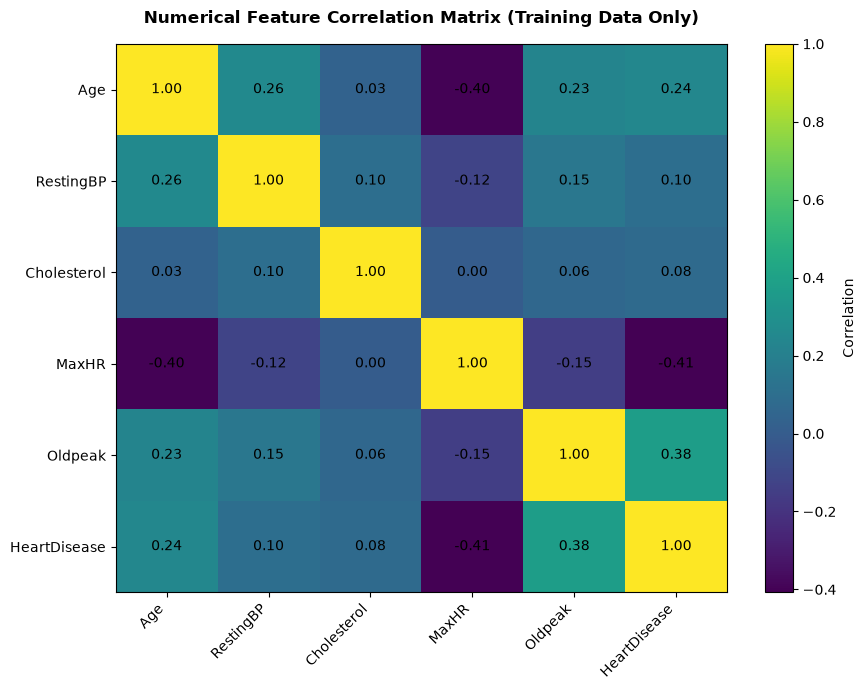

Numerical correlation outputs saved successfully.


In [173]:
# ============================================================
# FINAL AUDIT FIX — SAVE NUMERICAL CORRELATION OUTPUTS
# ============================================================

# Use TRAINING DATA ONLY for feature analysis
correlation_data = X_train[
    numerical_features
].copy()

correlation_data["HeartDisease"] = y_train

# Calculate correlation matrix
numerical_correlation_matrix = (
    correlation_data.corr()
)

# Extract correlations between numerical predictors
# and the HeartDisease target
correlation_scores = (
    numerical_correlation_matrix[
        "HeartDisease"
    ]
    .drop("HeartDisease")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
    .reset_index()
)

correlation_scores.columns = [
    "Feature",
    "Correlation_with_HeartDisease"
]

# Save correlation scores table
save_table(
    correlation_scores,
    "correlation_scores.csv",
    index=False
)

display(correlation_scores)


# ------------------------------------------------------------
# CREATE CORRELATION HEATMAP
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 7)
)

heatmap = ax.imshow(
    numerical_correlation_matrix,
    aspect="auto"
)

feature_names = (
    numerical_correlation_matrix.columns.tolist()
)

ax.set_xticks(
    range(len(feature_names))
)

ax.set_yticks(
    range(len(feature_names))
)

ax.set_xticklabels(
    feature_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    feature_names
)

# Add correlation values inside each cell
for row in range(
    len(feature_names)
):
    for column in range(
        len(feature_names)
    ):
        ax.text(
            column,
            row,
            f"{numerical_correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title(
    "Numerical Feature Correlation Matrix "
    "(Training Data Only)",
    fontweight="bold",
    pad=15
)

fig.colorbar(
    heatmap,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()

save_chart(
    "numerical_correlation_heatmap.png",
    "feature_analysis",
    fig=fig
)

plt.show()

print(
    "Numerical correlation outputs saved successfully."
)


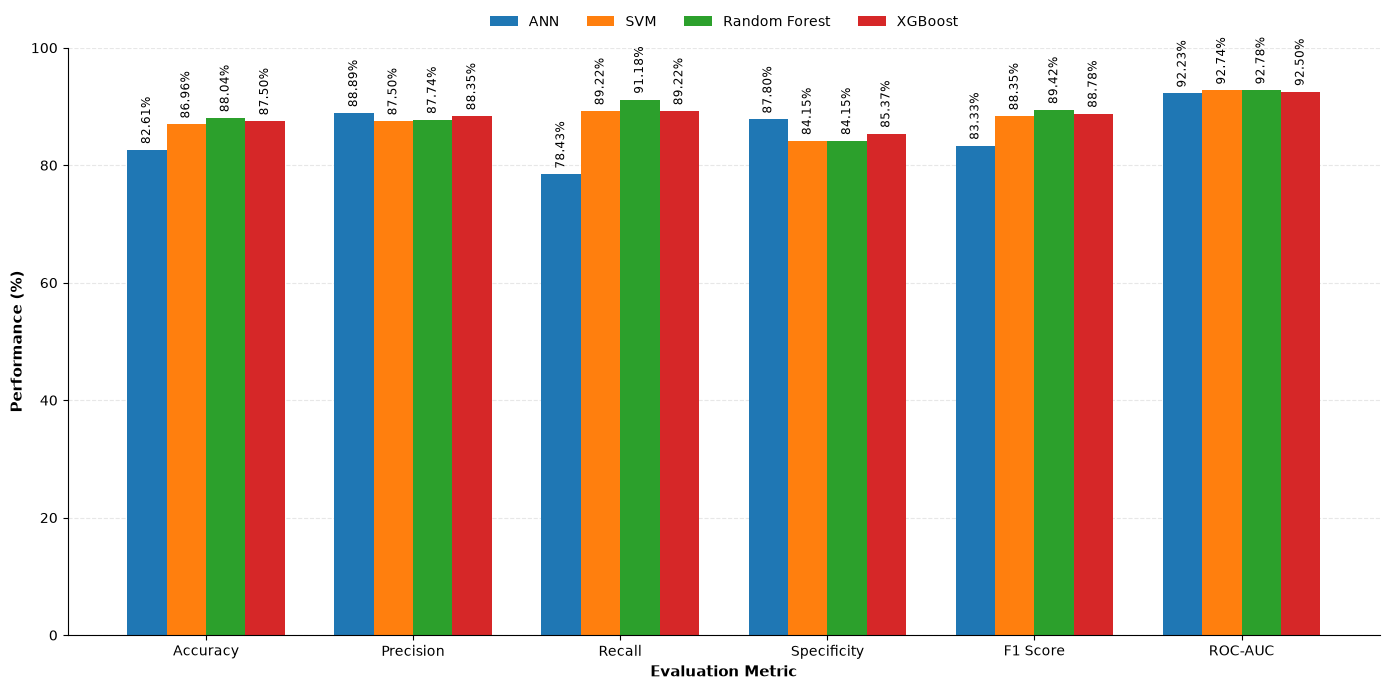

In [185]:
import numpy as np
import matplotlib.pyplot as plt

# Final untouched test-set performance (%)
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1 Score",
    "ROC-AUC"
]

ann = [82.61, 88.89, 78.43, 87.80, 83.33, 92.23]
svm = [86.96, 87.50, 89.22, 84.15, 88.35, 92.74]
rf = [88.04, 87.74, 91.18, 84.15, 89.42, 92.78]
xgb = [87.50, 88.35, 89.22, 85.37, 88.78, 92.50]

x = np.arange(len(metrics))
width = 0.19

fig, ax = plt.subplots(figsize=(14, 7))

# Grouped bars
bars_ann = ax.bar(x - 1.5 * width, ann, width, label="ANN")
bars_svm = ax.bar(x - 0.5 * width, svm, width, label="SVM")
bars_rf = ax.bar(x + 0.5 * width, rf, width, label="Random Forest")
bars_xgb = ax.bar(x + 1.5 * width, xgb, width, label="XGBoost")

# Exact percentage labels above bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.0,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=8.5,
            rotation=90
        )

add_labels(bars_ann)
add_labels(bars_svm)
add_labels(bars_rf)
add_labels(bars_xgb)

# Axis formatting
ax.set_ylabel("Performance (%)", fontsize=11, fontweight="bold")
ax.set_xlabel("Evaluation Metric", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)

ax.set_ylim(0, 100)

# Light horizontal grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Legend
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    frameon=False,
    fontsize=10
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# High-resolution image for the report
plt.savefig(
    "Figure_4_1_Final_Model_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
